# Activity Distance LFP: Morlet Coherence Over Distance

This notebook estimates distance-dependent LFP coherence using the Gireesh and Plenz-style logic: Morlet wavelet coefficients are computed for each nested oscillation period, the active cortical site with the largest nLFP deflection is used as the reference, and coherence from that site to all other active sites is binned by distance. A time-shifted segment with the same active sites/reference provides the control.

In [130]:
%matplotlib inline

import json
import os
import sys
import hashlib
import pickle
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import butter, fftconvolve, sosfiltfilt

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str((repo_root / ".mpl-cache").resolve()))

from ephax.metrics.burst import BurstActivityConfig, build_single_recording_burst_state
from ephax.metrics.lfp import bandpass_downsample, dataset_for_well, inspect_file, load_chunk, load_data_store_spikes
from ephax.preprocessing.dataset import Recording

plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 120)
np.random.seed(0)


## Configuration

In [131]:
def env_int(name, default):
    return int(os.environ.get(name, str(default)))


def env_float(name, default):
    return float(os.environ.get(name, str(default)))


def env_str(name, default):
    return os.environ.get(name, str(default)).strip()


def env_bool(name, default=False):
    value = os.environ.get(name)
    if value is None:
        return bool(default)
    return str(value).strip().lower() in {"1", "true", "yes", "y"}


def env_optional_int(name, default=None):
    value = os.environ.get(name)
    if value is None or str(value).strip() == "":
        return default
    return int(value)


DIV = 12
AGGREGATE_WELLS = [0, 1]
BURST_DETECTION_MODE = env_str("LFP_COH_BURST_DETECTOR", "nlfp").lower()  # "nlfp" or "spike"
LFP_SOURCE = "stim_removal_null_lfp"
STIM_REMOVAL_NULL_LFP_ROOT = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull")
RAW_LFP_FILE = STIM_REMOVAL_NULL_LFP_ROOT / f"DIV {int(DIV)}" / "data.raw.h5"
START_SEC = env_float("LFP_COH_START_SEC", 0.0)
END_SEC = env_float("LFP_COH_END_SEC", 600.0)
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000

# Use the same burst-state workflow and parameters as Figure 2.
IFR_GRID_HZ = 50.0
IFR_MAX_HZ = 1000.0
SMOOTH_SIGMA_SEC = 0.15
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0

# Gireesh/Plenz-style time-frequency coherence settings.
WAVELET_LOW_HZ = 4.0
WAVELET_HIGH_HZ = 100.0
SUBOCTAVES = 12
MORLET_N_CYCLES = 7.0
COHERENCE_FS_HZ = 500.0
COHERENCE_FILTER_LOW_HZ = 4.0
COHERENCE_FILTER_HIGH_HZ = 120.0
BACKGROUND_SHIFT_MAX_S = 1.0
BACKGROUND_SHIFT_REPS = env_int("LFP_COH_BACKGROUND_SHIFT_REPS", 1)
BACKGROUND_SHIFT_MODE = env_str("LFP_COH_SHIFT_MODE", "segment").lower()  # "segment" or "independent"
BACKGROUND_RANDOM_SEED = 0
LINE_NOISE_EXCLUSION_HZ = (58.0, 62.0)

# Gireesh/Plenz-style nLFP burst detector. Data are converted to microvolts before thresholding.
NLFP_THRESHOLD_UV = env_float("LFP_COH_NLFP_THRESHOLD_UV", 8.0)
NLFP_THRESHOLD_SD = env_float("LFP_COH_NLFP_THRESHOLD_SD", 8.0)
NLFP_THRESHOLD_MODE = env_str("LFP_COH_NLFP_THRESHOLD_MODE", "uv").lower()  # "uv" or "sd"
NLFP_CHUNK_S = env_float("LFP_COH_NLFP_CHUNK_S", 30.0)
NLFP_PEAK_MIN_DISTANCE_MS = env_float("LFP_COH_NLFP_PEAK_MIN_DISTANCE_MS", 20.0)
NLFP_POP_BIN_MS = env_float("LFP_COH_NLFP_POP_BIN_MS", 1.0)
NLFP_POP_SMOOTH_SIGMA_MS = env_float("LFP_COH_NLFP_POP_SMOOTH_SIGMA_MS", 30.0)
NLFP_POP_LOWPASS_HZ = env_float("LFP_COH_NLFP_POP_LOWPASS_HZ", 10.0)
NLFP_POP_THRESHOLD_MAD_SCALE = env_float("LFP_COH_NLFP_POP_THRESHOLD_MAD_SCALE", 3.0)
NLFP_MIN_BURST_DURATION_MS = env_float("LFP_COH_NLFP_MIN_BURST_DURATION_MS", 30.0)
NLFP_MAX_GAP_BINS = env_int("LFP_COH_NLFP_MAX_GAP_BINS", 1)
NLFP_DETECTION_MAX_CHANNELS = env_optional_int("LFP_COH_NLFP_MAX_CHANNELS")
NLFP_SEARCH_MODE = env_str("LFP_COH_NLFP_SEARCH_MODE", "high_activity").lower()  # "high_activity", "spike_bursts", or "full"
NLFP_SEARCH_PAD_S = env_float("LFP_COH_NLFP_SEARCH_PAD_S", 0.05)
NLFP_ANCHOR_MODE = env_str("LFP_COH_NLFP_ANCHOR_MODE", "population_lfp_min").lower()
NLFP_DETECTOR_VERSION = "population_lfp_anchor_v4"
LFP_COHERENCE_ANALYSIS_VERSION = "binned_color_map_coherence_v1"

FREQUENCY_BANDS = {
    "theta": (4.0, 8.0),
    "beta": (12.0, 30.0),
    "gamma": (30.0, 100.0),
}

MIN_DISTANCE_UM = 50.0
MAX_DISTANCE_UM = 3500.0
DISTANCE_BIN_UM = 100.0
MAX_EVENTS_PER_WELL = env_int("LFP_COH_MAX_EVENTS_PER_WELL", 10)
MAX_ACTIVE_SITES_PER_EVENT = env_int("LFP_COH_MAX_ACTIVE_SITES", 100)
BOOTSTRAP_REPS = env_int("LFP_COH_BOOTSTRAP_REPS", 1000)
BOOTSTRAP_SEED = 0
FORCE_RECOMPUTE = env_bool("LFP_COH_FORCE_RECOMPUTE", False)
STORE_SITE_ROWS = False
SPECTROGRAM_N_EVENTS = env_int("LFP_COH_SPECTROGRAM_EVENTS", 10)
SPECTROGRAM_N_ELECTRODES = env_int("LFP_COH_SPECTROGRAM_ELECTRODES", 12)
SPECTROGRAM_PAD_S = 0.25
WAVELET_COHERENCE_SMOOTH_FREQ_BINS = env_float("LFP_COH_TF_SMOOTH_FREQ_BINS", 1.0)
WAVELET_COHERENCE_SMOOTH_TIME_MS = env_float("LFP_COH_TF_SMOOTH_TIME_MS", 20.0)

OUTPUT_DIR = repo_root / "outputs" / "lfp_coherence_distance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BURST_CONFIG = BurstActivityConfig(
    wells=tuple(AGGREGATE_WELLS),
    start_sec=START_SEC,
    end_sec=END_SEC,
    ifr_grid_hz=IFR_GRID_HZ,
    ifr_max_hz=IFR_MAX_HZ,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    highres_bin_ms=HIGHRES_BIN_MS,
    highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
    network_bin_ms=NETWORK_BIN_MS,
    high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    network_min_duration_ms=NETWORK_MIN_DURATION_MS,
)

CACHE_NOTE = (
    f"{LFP_SOURCE}; DIV{DIV}; Morlet {WAVELET_LOW_HZ:g}-{WAVELET_HIGH_HZ:g} Hz; "
    f"{SUBOCTAVES} suboctaves; detector={BURST_DETECTION_MODE}; nlfp_search={NLFP_SEARCH_MODE}; "
    f"shifted n={BACKGROUND_SHIFT_REPS}, max={BACKGROUND_SHIFT_MAX_S:g}s"
)


## Cache Paths and Loaders

In [132]:
def _recording_for_well(well):
    dataset = dataset_for_well(well)
    info = inspect_file(RAW_LFP_FILE, dataset)
    spikes, layout, sf = load_data_store_spikes(RAW_LFP_FILE, dataset, min_amp=MIN_AMP)
    stop_s = min(
        float(END_SEC),
        info["raw_shape"][1] / float(info["fs_raw"]),
        float(np.nanmax(spikes["time"])) if len(spikes["time"]) else float(END_SEC),
    )
    keep = (np.asarray(spikes["time"], dtype=float) >= float(START_SEC)) & (np.asarray(spikes["time"], dtype=float) <= stop_s)
    spikes = {key: np.asarray(value)[keep] for key, value in spikes.items()}
    recording = Recording(spikes=spikes, layout=layout, start_time=float(START_SEC), end_time=stop_s, sf=float(sf))
    return recording, dataset, info


def _burst_active_electrode_rows(recording, burst_epochs):
    spike_time = np.asarray(recording.spikes["time"], dtype=float)
    spike_electrode = np.asarray(recording.spikes["electrode"], dtype=int)
    rows = []
    for event in burst_epochs.itertuples(index=False):
        in_event = (spike_time >= float(event.start_time_s)) & (spike_time <= float(event.end_time_s))
        if not np.any(in_event):
            continue
        electrodes, counts = np.unique(spike_electrode[in_event], return_counts=True)
        first_times = {int(el): float(np.nanmin(spike_time[in_event & (spike_electrode == int(el))])) for el in electrodes}
        for electrode, count in zip(electrodes, counts):
            rows.append({
                "event_idx": int(event.event_idx),
                "electrode": int(electrode),
                "total_spikes": int(count),
                "first_spike_time_s": first_times[int(electrode)],
            })
    return pd.DataFrame(rows)


def _merge_short_inactive_gaps(active, max_gap_bins):
    active = np.asarray(active, dtype=bool).copy()
    if int(max_gap_bins) <= 0 or active.size == 0:
        return active
    idx = 0
    while idx < active.size:
        if active[idx]:
            idx += 1
            continue
        start = idx
        while idx < active.size and not active[idx]:
            idx += 1
        stop = idx
        if start > 0 and stop < active.size and (stop - start) <= int(max_gap_bins):
            active[start:stop] = True
    return active


def _active_epoch_bounds(active):
    active = np.asarray(active, dtype=bool)
    if active.size == 0:
        return []
    starts = np.flatnonzero(active & np.r_[True, ~active[:-1]])
    stops = np.flatnonzero(active & np.r_[~active[1:], True]) + 1
    return list(zip(starts, stops))


def _merge_intervals(intervals, *, start_s=START_SEC, stop_s=END_SEC):
    cleaned = []
    for start, stop in intervals:
        start = max(float(start_s), float(start))
        stop = min(float(stop_s), float(stop))
        if stop > start:
            cleaned.append((start, stop))
    if not cleaned:
        return []
    cleaned.sort()
    merged = [cleaned[0]]
    for start, stop in cleaned[1:]:
        last_start, last_stop = merged[-1]
        if start <= last_stop:
            merged[-1] = (last_start, max(last_stop, stop))
        else:
            merged.append((start, stop))
    return merged


def _spike_candidate_bursts_for_well(well):
    bursts, local, dataset, extra = _spike_burst_tables_for_well(int(well))
    if bursts.empty:
        return bursts, local, dataset, extra, []
    intervals = _merge_intervals(
        zip(
            bursts["start_time_s"].astype(float) - float(NLFP_SEARCH_PAD_S),
            bursts["end_time_s"].astype(float) + float(NLFP_SEARCH_PAD_S),
        )
    )
    return bursts, local, dataset, extra, intervals


def _spike_high_activity_intervals_for_well(well):
    recording, dataset, info = _recording_for_well(int(well))
    refs = recording.refs_top(start=TOP_START, stop=TOP_STOP)
    state = build_single_recording_burst_state(recording, refs, config=BURST_CONFIG)
    high = state["high_activity_epochs"].copy()
    extra = {
        "n_high_activity_epochs": int(len(high)),
        "n_spike_bursts": int(len(state["burst_epochs"])),
    }
    if high.empty:
        return high, dataset, extra, []
    intervals = _merge_intervals(
        zip(
            high["start_time_s"].astype(float) - float(NLFP_SEARCH_PAD_S),
            high["end_time_s"].astype(float) + float(NLFP_SEARCH_PAD_S),
        )
    )
    return high, dataset, extra, intervals


def _lowpass_nlfp_population(counts, bin_s):
    counts = np.asarray(counts, dtype=float)
    if counts.size == 0:
        return counts
    fs = 1.0 / float(bin_s)
    cutoff = float(NLFP_POP_LOWPASS_HZ)
    if cutoff <= 0 or cutoff >= 0.45 * fs or counts.size < 16:
        return counts
    sos = butter(4, cutoff, btype="lowpass", fs=fs, output="sos")
    padlen = min(counts.size - 1, 3 * (2 * sos.shape[0] + 1))
    if padlen < 1:
        return counts
    return sosfiltfilt(sos, counts, padlen=padlen)


def _append_nlfp_event_rows(event_rows, local_rows, nlfp, epoch_start, epoch_stop, anchor, population_peak, threshold):
    in_event = (nlfp["time_s"].to_numpy(float) >= float(epoch_start)) & (nlfp["time_s"].to_numpy(float) <= float(epoch_stop))
    event_nlfp = nlfp.loc[in_event]
    if event_nlfp.empty:
        return
    event_rows.append({
        "event_idx": len(event_rows),
        "start_time_s": float(epoch_start),
        "end_time_s": float(epoch_stop),
        "anchor_time_s": float(anchor),
        "duration_ms": 1000.0 * (float(epoch_stop) - float(epoch_start)),
        "nlfp_population_peak": float(population_peak),
        "nlfp_population_threshold": float(threshold) if np.isfinite(threshold) else np.nan,
    })
    for electrode, group in event_nlfp.groupby("electrode", sort=False):
        local_rows.append({
            "event_idx": len(event_rows) - 1,
            "electrode": int(electrode),
            "total_spikes": int(len(group)),
            "total_nlfp": int(len(group)),
            "first_spike_time_s": float(group["time_s"].min()),
            "first_nlfp_time_s": float(group["time_s"].min()),
            "min_nlfp_amplitude_uv": float(group["nlfp_amplitude_uv"].min()),
        })


def _population_events_from_nlfp(nlfp, search_intervals, population_lfp=None):
    event_rows = []
    local_rows = []
    thresholds = []
    trace_rows = []
    population_lfp = pd.DataFrame() if population_lfp is None else population_lfp
    bin_s = float(NLFP_POP_BIN_MS) * 1e-3
    min_duration_s = float(NLFP_MIN_BURST_DURATION_MS) * 1e-3
    for interval_start, interval_stop in search_intervals:
        interval_nlfp = nlfp.loc[
            (nlfp["time_s"].to_numpy(float) >= float(interval_start))
            & (nlfp["time_s"].to_numpy(float) <= float(interval_stop))
        ]
        if interval_nlfp.empty:
            continue
        edges = np.arange(float(interval_start), float(interval_stop) + bin_s, bin_s, dtype=float)
        if edges.size < 2 or edges[-1] < float(interval_stop):
            edges = np.append(edges, float(interval_stop))
        counts, _ = np.histogram(interval_nlfp["time_s"].to_numpy(float), bins=edges)
        population = _lowpass_nlfp_population(counts.astype(float), bin_s)
        centers = 0.5 * (edges[:-1] + edges[1:])
        lfp_interval = population_lfp.loc[
            (population_lfp["time_s"].to_numpy(float) >= float(interval_start))
            & (population_lfp["time_s"].to_numpy(float) <= float(interval_stop))
        ] if not population_lfp.empty else pd.DataFrame()
        lfp_binned = np.full(counts.shape, np.nan, dtype=float)
        if not lfp_interval.empty:
            lfp_bin_idx = np.searchsorted(edges, lfp_interval["time_s"].to_numpy(float), side="right") - 1
            for b in np.unique(lfp_bin_idx[(lfp_bin_idx >= 0) & (lfp_bin_idx < lfp_binned.size)]):
                vals = lfp_interval.loc[lfp_bin_idx == b, "population_lfp_uv"].to_numpy(float)
                if vals.size:
                    lfp_binned[int(b)] = float(np.nanmean(vals))
        baseline = float(np.nanmedian(population))
        mad = float(np.nanmedian(np.abs(population - baseline)))
        threshold = baseline + float(NLFP_POP_THRESHOLD_MAD_SCALE) * 1.4826 * mad
        if not np.isfinite(threshold) or threshold <= 0:
            threshold = max(1.0, baseline)
        thresholds.append(threshold)
        trace_rows.append(pd.DataFrame({
            "time_s": centers,
            "nlfp_count": counts.astype(float),
            "nlfp_population": population.astype(float),
            "population_threshold": float(threshold),
            "population_lfp_uv": lfp_binned,
            "search_interval_start_s": float(interval_start),
            "search_interval_stop_s": float(interval_stop),
        }))
        active = _merge_short_inactive_gaps(population > threshold, NLFP_MAX_GAP_BINS)
        for start_bin, stop_bin in _active_epoch_bounds(active):
            epoch_start = float(edges[start_bin])
            epoch_stop = float(edges[min(stop_bin, edges.size - 1)])
            if epoch_stop - epoch_start < min_duration_s:
                continue
            local_peak_bin = start_bin + int(np.nanargmax(population[start_bin:stop_bin]))
            anchor = float(0.5 * (edges[local_peak_bin] + edges[min(local_peak_bin + 1, edges.size - 1)]))
            if NLFP_ANCHOR_MODE == "population_lfp_min" and np.any(np.isfinite(lfp_binned[start_bin:stop_bin])):
                local_lfp_bin = start_bin + int(np.nanargmin(lfp_binned[start_bin:stop_bin]))
                anchor = float(0.5 * (edges[local_lfp_bin] + edges[min(local_lfp_bin + 1, edges.size - 1)]))
            _append_nlfp_event_rows(
                event_rows,
                local_rows,
                nlfp,
                epoch_start,
                epoch_stop,
                anchor,
                float(population[local_peak_bin]),
                threshold,
            )
    trace = pd.concat(trace_rows, ignore_index=True) if trace_rows else pd.DataFrame()
    return pd.DataFrame(event_rows), pd.DataFrame(local_rows), thresholds, trace


def _vectorized_nlfp_rows(data_uv, electrodes, chunk_time, thresholds, interval_start_s, interval_stop_s, peak_distance):
    data_uv = np.asarray(data_uv, dtype=float)
    if data_uv.shape[0] < 3 or data_uv.shape[1] < 1:
        return []
    thresholds = np.asarray(thresholds, dtype=float)
    below = data_uv <= -thresholds[None, :]
    if not np.any(below):
        return []
    padded = np.pad(below, ((1, 1), (0, 0)), constant_values=False)
    transitions = np.diff(padded.astype(np.int8), axis=0)
    start_samples, start_channels = np.nonzero(transitions == 1)
    stop_samples, stop_channels = np.nonzero(transitions == -1)
    if start_samples.size == 0:
        return []
    rows = []
    last_by_channel = {}
    # Threshold-crossing events are sparse compared with samples; loop over excursions, not channels x full traces.
    for chan_idx in np.unique(start_channels):
        starts = start_samples[start_channels == chan_idx]
        stops = stop_samples[stop_channels == chan_idx]
        n = min(starts.size, stops.size)
        if n == 0:
            continue
        accepted = []
        for start, stop in zip(starts[:n], stops[:n]):
            if stop <= start:
                continue
            segment = data_uv[int(start):int(stop), int(chan_idx)]
            if segment.size == 0:
                continue
            peak_sample = int(start) + int(np.nanargmin(segment))
            if accepted and abs(peak_sample - accepted[-1]) < int(peak_distance):
                # Keep the more negative of two too-close excursions.
                if data_uv[peak_sample, int(chan_idx)] < data_uv[accepted[-1], int(chan_idx)]:
                    accepted[-1] = peak_sample
                continue
            accepted.append(peak_sample)
        for sample in accepted:
            time_s = float(chunk_time[int(sample)])
            if float(interval_start_s) <= time_s <= float(interval_stop_s):
                rows.append({
                    "time_s": time_s,
                    "electrode": int(electrodes[int(chan_idx)]),
                    "nlfp_amplitude_uv": float(data_uv[int(sample), int(chan_idx)]),
                })
    return rows

def _detect_nlfp_events_for_well(well, search_intervals=None, candidate_bursts=None):
    dataset = dataset_for_well(well)
    info = inspect_file(RAW_LFP_FILE, dataset)
    fs_raw = float(info["fs_raw"])
    recording_stop_s = float(info["raw_shape"][1]) / fs_raw
    start_s = max(float(START_SEC), 0.0)
    stop_s = min(float(END_SEC), recording_stop_s)
    search_intervals = _merge_intervals(search_intervals or [(start_s, stop_s)], start_s=start_s, stop_s=stop_s)
    chunk_frames = max(1, int(round(float(NLFP_CHUNK_S) * fs_raw)))
    peak_distance = max(1, int(round(float(NLFP_PEAK_MIN_DISTANCE_MS) * 1e-3 * float(COHERENCE_FS_HZ))))
    rows = []
    population_lfp_parts = []

    selected_channels = None
    if NLFP_DETECTION_MAX_CHANNELS is not None:
        first_frame = int(round(search_intervals[0][0] * fs_raw)) if search_intervals else int(round(start_s * fs_raw))
        _, _, _, full_mapping = load_chunk(RAW_LFP_FILE, dataset, first_frame, 1)
        channels = np.asarray(full_mapping["channel"], dtype=int)
        if channels.size > int(NLFP_DETECTION_MAX_CHANNELS):
            pick = np.round(np.linspace(0, channels.size - 1, int(NLFP_DETECTION_MAX_CHANNELS))).astype(int)
            channels = channels[pick]
        selected_channels = channels

    for interval_start_s, interval_stop_s in search_intervals:
        start_frame = int(round(interval_start_s * fs_raw))
        stop_frame = int(round(interval_stop_s * fs_raw))
        for chunk_start in range(start_frame, stop_frame, chunk_frames):
            n_frames = min(chunk_frames, stop_frame - chunk_start)
            raw, coords_mm, fs_loaded, mapping = load_chunk(RAW_LFP_FILE, dataset, chunk_start, n_frames, channels=selected_channels)
            if raw.shape[0] < 8 or raw.shape[1] < 2:
                continue
            band = bandpass_downsample(
                raw,
                fs_loaded,
                COHERENCE_FILTER_LOW_HZ,
                COHERENCE_FILTER_HIGH_HZ,
                COHERENCE_FS_HZ,
                max_channels_per_block=128,
            )
            data_uv = np.asarray(band, dtype=float) * 1e6
            electrodes = np.asarray(mapping["electrode"], dtype=int)
            t0 = float(chunk_start) / fs_raw
            chunk_time = t0 + np.arange(data_uv.shape[0], dtype=float) / float(COHERENCE_FS_HZ)
            population_lfp_parts.append(pd.DataFrame({
                "time_s": chunk_time,
                "population_lfp_uv": np.nanmean(data_uv, axis=1),
            }))
            if NLFP_THRESHOLD_MODE == "sd":
                med = np.nanmedian(data_uv, axis=0)
                mad = np.nanmedian(np.abs(data_uv - med[None, :]), axis=0)
                thresholds = np.maximum(float(NLFP_THRESHOLD_UV), float(NLFP_THRESHOLD_SD) * 1.4826 * mad)
            else:
                thresholds = np.full(data_uv.shape[1], float(NLFP_THRESHOLD_UV), dtype=float)
            rows.extend(_vectorized_nlfp_rows(data_uv, electrodes, chunk_time, thresholds, interval_start_s, interval_stop_s, peak_distance))

    nlfp = pd.DataFrame(rows)
    population_lfp = pd.concat(population_lfp_parts, ignore_index=True) if population_lfp_parts else pd.DataFrame()
    search_duration_s = float(sum(stop - start for start, stop in search_intervals))
    if nlfp.empty:
        return pd.DataFrame(), pd.DataFrame(), {
            "n_nlfp": 0,
            "nlfp_search_intervals": int(len(search_intervals)),
            "nlfp_search_duration_s": search_duration_s,
            "population_threshold": np.nan,
            "population_trace": pd.DataFrame(),
        }

    if candidate_bursts is not None and not candidate_bursts.empty:
        event_rows = []
        local_rows = []
        candidates = candidate_bursts.sort_values("anchor_time_s").reset_index(drop=True)
        for _, candidate in candidates.iterrows():
            epoch_start = float(candidate["start_time_s"])
            epoch_stop = float(candidate["end_time_s"])
            in_event = (nlfp["time_s"].to_numpy(float) >= epoch_start) & (nlfp["time_s"].to_numpy(float) <= epoch_stop)
            event_nlfp = nlfp.loc[in_event]
            if event_nlfp.empty:
                continue
            peak_row = event_nlfp.loc[event_nlfp["nlfp_amplitude_uv"].idxmin()]
            _append_nlfp_event_rows(event_rows, local_rows, nlfp, epoch_start, epoch_stop, float(peak_row["time_s"]), float(len(event_nlfp)), np.nan)
        return pd.DataFrame(event_rows), pd.DataFrame(local_rows), {
            "n_nlfp": int(len(nlfp)),
            "nlfp_search_intervals": int(len(search_intervals)),
            "nlfp_search_duration_s": search_duration_s,
            "population_threshold": np.nan,
            "population_bin_ms": float(NLFP_POP_BIN_MS),
            "population_trace": pd.DataFrame(),
        }

    bursts, local, thresholds, population_trace = _population_events_from_nlfp(nlfp, search_intervals, population_lfp=population_lfp)
    return bursts, local, {
        "n_nlfp": int(len(nlfp)),
        "nlfp_search_intervals": int(len(search_intervals)),
        "nlfp_search_duration_s": search_duration_s,
        "population_threshold": float(np.nanmedian(thresholds)) if thresholds else np.nan,
        "population_bin_ms": float(NLFP_POP_BIN_MS),
        "population_trace": population_trace,
    }

def _spike_burst_tables_for_well(well):
    recording, dataset, info = _recording_for_well(int(well))
    refs = recording.refs_top(start=TOP_START, stop=TOP_STOP)
    state = build_single_recording_burst_state(recording, refs, config=BURST_CONFIG)
    bursts = state["burst_epochs"].copy()
    local = pd.DataFrame()
    extra = {"n_high_activity_epochs": len(state["high_activity_epochs"])}
    if not bursts.empty:
        bursts = bursts.sort_values("anchor_time_s").reset_index(drop=True)
        bursts["event_idx"] = np.arange(len(bursts), dtype=int)
        local = _burst_active_electrode_rows(recording, bursts)
    return bursts, local, dataset, extra


def _nlfp_burst_tables_for_well(well):
    dataset = dataset_for_well(int(well))
    candidate_bursts = None
    search_intervals = None
    spike_extra = {}
    if NLFP_SEARCH_MODE == "high_activity":
        _, dataset, spike_extra, search_intervals = _spike_high_activity_intervals_for_well(int(well))
        if not search_intervals:
            return pd.DataFrame(), pd.DataFrame(), dataset, {"nlfp_search_intervals": 0, "nlfp_search_duration_s": 0.0, **spike_extra}
    elif NLFP_SEARCH_MODE == "spike_bursts":
        candidate_bursts, _, dataset, spike_extra, search_intervals = _spike_candidate_bursts_for_well(int(well))
        if candidate_bursts.empty or not search_intervals:
            return pd.DataFrame(), pd.DataFrame(), dataset, {"nlfp_search_intervals": 0, "nlfp_search_duration_s": 0.0, **spike_extra}
    elif NLFP_SEARCH_MODE != "full":
        raise ValueError("NLFP_SEARCH_MODE must be 'high_activity', 'spike_bursts', or 'full'")
    bursts, local, extra = _detect_nlfp_events_for_well(int(well), search_intervals=search_intervals, candidate_bursts=candidate_bursts)
    return bursts, local, dataset, {"n_high_activity_epochs": int(spike_extra.get("n_high_activity_epochs", len(bursts))), **spike_extra, **extra}


def build_burst_tables(wells):
    event_parts = []
    local_parts = []
    population_parts = []
    summary_rows = []
    if BURST_DETECTION_MODE not in {"spike", "nlfp"}:
        raise ValueError("BURST_DETECTION_MODE must be 'spike' or 'nlfp'")
    for well in wells:
        if BURST_DETECTION_MODE == "nlfp":
            bursts, local, dataset, extra = _nlfp_burst_tables_for_well(int(well))
        else:
            bursts, local, dataset, extra = _spike_burst_tables_for_well(int(well))
        population_trace = extra.pop("population_trace", pd.DataFrame())
        if not population_trace.empty:
            population_trace = population_trace.copy()
            population_trace.insert(0, "well", int(well))
            population_trace["raw_file"] = str(RAW_LFP_FILE)
            population_trace["dataset"] = dataset
            population_parts.append(population_trace)
        if bursts.empty:
            summary_rows.append({
                "well": int(well), "raw_file": str(RAW_LFP_FILE), "dataset": dataset,
                "detector": BURST_DETECTION_MODE, "n_events": 0, "n_local_rows": 0, **extra,
            })
            continue
        bursts = bursts.copy().sort_values("anchor_time_s").reset_index(drop=True)
        bursts["event_idx"] = np.arange(len(bursts), dtype=int)
        bursts["coherence_start_s"] = bursts["start_time_s"].astype(float)
        bursts["coherence_stop_s"] = bursts["end_time_s"].astype(float)
        bursts["coherence_window_s"] = bursts["coherence_stop_s"] - bursts["coherence_start_s"]
        t_burst_s = float(np.nanmean(bursts["coherence_window_s"].to_numpy(float)))
        bursts.insert(0, "well", int(well))
        bursts["raw_file"] = str(RAW_LFP_FILE)
        bursts["dataset"] = dataset
        bursts["detector"] = BURST_DETECTION_MODE
        if not local.empty:
            local = local.copy()
            local.insert(0, "well", int(well))
            local["raw_file"] = str(RAW_LFP_FILE)
            local["dataset"] = dataset
            local["detector"] = BURST_DETECTION_MODE
        event_parts.append(bursts)
        local_parts.append(local)
        summary_rows.append({
            "well": int(well),
            "raw_file": str(RAW_LFP_FILE),
            "dataset": dataset,
            "detector": BURST_DETECTION_MODE,
            "n_events": int(len(bursts)),
            "n_local_rows": int(len(local)),
            "mean_burst_duration_s": t_burst_s,
            "median_active_electrodes_per_event": float(local.groupby("event_idx")["electrode"].nunique().median()) if not local.empty else np.nan,
            **extra,
        })
    event_df = pd.concat(event_parts, ignore_index=True) if event_parts else pd.DataFrame()
    local_df = pd.concat(local_parts, ignore_index=True) if local_parts else pd.DataFrame()
    population_df = pd.concat(population_parts, ignore_index=True) if population_parts else pd.DataFrame()
    cache_summary = pd.DataFrame(summary_rows)
    return event_df, local_df, cache_summary, population_df


## Morlet Coherence Over Distance

In [133]:
def distance_edges_and_centers():
    edges = np.arange(MIN_DISTANCE_UM, MAX_DISTANCE_UM + DISTANCE_BIN_UM, DISTANCE_BIN_UM, dtype=float)
    if edges[-1] < MAX_DISTANCE_UM:
        edges = np.append(edges, MAX_DISTANCE_UM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, centers


def morlet_frequencies(low_hz=WAVELET_LOW_HZ, high_hz=WAVELET_HIGH_HZ, suboctaves=SUBOCTAVES):
    exponents = np.arange(np.log2(float(low_hz)), np.log2(float(high_hz)) + 1e-9, 1.0 / int(suboctaves))
    freqs = 2.0 ** exponents
    return freqs[freqs <= float(high_hz) * (1.0 + 1e-9)]


WAVELET_FREQS_HZ = morlet_frequencies()
print(f"Morlet frequencies: {len(WAVELET_FREQS_HZ)} bins from {WAVELET_FREQS_HZ[0]:.2f} to {WAVELET_FREQS_HZ[-1]:.2f} Hz")


def analysis_cache_key():
    payload = {
        "analysis_version": LFP_COHERENCE_ANALYSIS_VERSION,
        "raw_file": str(RAW_LFP_FILE),
        "burst_detection": BURST_DETECTION_MODE,
        "burst_config": BURST_CONFIG.__dict__,
        "top_range": [int(TOP_START), int(TOP_STOP)],
        "wavelet_freqs": np.round(WAVELET_FREQS_HZ, 6).tolist(),
        "bands": FREQUENCY_BANDS,
        "coherence_window": "detected_burst_start_stop",
        "background_shift_mode": BACKGROUND_SHIFT_MODE,
        "nlfp_detector": {
            "detector_version": NLFP_DETECTOR_VERSION,
            "threshold_uv": float(NLFP_THRESHOLD_UV),
            "threshold_sd": float(NLFP_THRESHOLD_SD),
            "threshold_mode": NLFP_THRESHOLD_MODE,
            "chunk_s": float(NLFP_CHUNK_S),
            "peak_min_distance_ms": float(NLFP_PEAK_MIN_DISTANCE_MS),
            "population_bin_ms": float(NLFP_POP_BIN_MS),
            "population_smooth_sigma_ms": float(NLFP_POP_SMOOTH_SIGMA_MS),
            "population_lowpass_hz": float(NLFP_POP_LOWPASS_HZ),
            "population_threshold_mad_scale": float(NLFP_POP_THRESHOLD_MAD_SCALE),
            "min_burst_duration_ms": float(NLFP_MIN_BURST_DURATION_MS),
            "max_gap_bins": int(NLFP_MAX_GAP_BINS),
            "max_channels": None if NLFP_DETECTION_MAX_CHANNELS is None else int(NLFP_DETECTION_MAX_CHANNELS),
            "search_mode": NLFP_SEARCH_MODE,
            "search_pad_s": float(NLFP_SEARCH_PAD_S),
            "anchor_mode": NLFP_ANCHOR_MODE,
        },
        "coherence_estimator": "smoothed_time_frequency_coherence_per_distance_bin",
        "background_shift_max_s": float(BACKGROUND_SHIFT_MAX_S),
        "background_shift_reps": int(BACKGROUND_SHIFT_REPS),
        "background_random_seed": int(BACKGROUND_RANDOM_SEED),
        "line_noise_exclusion_hz": list(map(float, LINE_NOISE_EXCLUSION_HZ)),
        "fs_hz": float(COHERENCE_FS_HZ),
        "filter": [float(COHERENCE_FILTER_LOW_HZ), float(COHERENCE_FILTER_HIGH_HZ)],
        "distance": [float(MIN_DISTANCE_UM), float(MAX_DISTANCE_UM), float(DISTANCE_BIN_UM)],
        "max_events_per_well": None if MAX_EVENTS_PER_WELL is None else int(MAX_EVENTS_PER_WELL),
        "max_active_sites": None if MAX_ACTIVE_SITES_PER_EVENT is None else int(MAX_ACTIVE_SITES_PER_EVENT),
        "store_site_rows": bool(STORE_SITE_ROWS),
    }
    text = json.dumps(payload, sort_keys=True)
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:16]


ANALYSIS_CACHE_PATH = OUTPUT_DIR / f"lfp_morlet_site_coherence_{analysis_cache_key()}.pkl"
ANALYSIS_CACHE_PATH


Morlet frequencies: 56 bins from 4.00 to 95.89 Hz


PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance/lfp_morlet_site_coherence_0ac887a799bc074e.pkl')

## Burst Detection Cache


In [134]:
def burst_table_cache_key():
    payload = {
        "raw_file": str(RAW_LFP_FILE),
        "wells": list(map(int, AGGREGATE_WELLS)),
        "start_sec": float(START_SEC),
        "end_sec": float(END_SEC),
        "detector": BURST_DETECTION_MODE,
        "spike_config": BURST_CONFIG.__dict__,
        "top_range": [int(TOP_START), int(TOP_STOP)],
        "nlfp_detector": {
            "detector_version": NLFP_DETECTOR_VERSION,
            "threshold_uv": float(NLFP_THRESHOLD_UV),
            "threshold_sd": float(NLFP_THRESHOLD_SD),
            "threshold_mode": NLFP_THRESHOLD_MODE,
            "chunk_s": float(NLFP_CHUNK_S),
            "filter": [float(COHERENCE_FILTER_LOW_HZ), float(COHERENCE_FILTER_HIGH_HZ)],
            "fs_hz": float(COHERENCE_FS_HZ),
            "peak_min_distance_ms": float(NLFP_PEAK_MIN_DISTANCE_MS),
            "population_bin_ms": float(NLFP_POP_BIN_MS),
            "population_smooth_sigma_ms": float(NLFP_POP_SMOOTH_SIGMA_MS),
            "population_lowpass_hz": float(NLFP_POP_LOWPASS_HZ),
            "population_threshold_mad_scale": float(NLFP_POP_THRESHOLD_MAD_SCALE),
            "min_burst_duration_ms": float(NLFP_MIN_BURST_DURATION_MS),
            "max_gap_bins": int(NLFP_MAX_GAP_BINS),
            "max_channels": None if NLFP_DETECTION_MAX_CHANNELS is None else int(NLFP_DETECTION_MAX_CHANNELS),
            "search_mode": NLFP_SEARCH_MODE,
            "search_pad_s": float(NLFP_SEARCH_PAD_S),
            "anchor_mode": NLFP_ANCHOR_MODE,
        },
    }
    return hashlib.sha1(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:16]


BURST_TABLE_CACHE_PATH = OUTPUT_DIR / f"lfp_burst_tables_{burst_table_cache_key()}.pkl"
if BURST_TABLE_CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with BURST_TABLE_CACHE_PATH.open("rb") as f:
        burst_cache = pickle.load(f)
    event_df = burst_cache["event_df"]
    local_df = burst_cache["local_df"]
    cache_summary = burst_cache["cache_summary"]
    nlfp_population_trace = burst_cache.get("nlfp_population_trace", pd.DataFrame())
    print(f"Loaded burst tables: {BURST_TABLE_CACHE_PATH}")
else:
    event_df, local_df, cache_summary, nlfp_population_trace = build_burst_tables(AGGREGATE_WELLS)
    with BURST_TABLE_CACHE_PATH.open("wb") as f:
        pickle.dump({"event_df": event_df, "local_df": local_df, "cache_summary": cache_summary, "nlfp_population_trace": nlfp_population_trace}, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Wrote burst tables: {BURST_TABLE_CACHE_PATH}")

display(cache_summary)
print(f"Detected burst events={len(event_df):,}; active-electrode rows={len(local_df):,}; wells={cache_summary['well'].nunique() if not cache_summary.empty else 0}; detector={BURST_DETECTION_MODE}")


Wrote burst tables: /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance/lfp_burst_tables_f6ffdc94d6185504.pkl


,well,raw_file,dataset,detector,n_events,n_local_rows,mean_burst_duration_s,median_active_electrodes_per_event,n_high_activity_epochs,n_spike_bursts,n_nlfp,nlfp_search_intervals,nlfp_search_duration_s,population_threshold,population_bin_ms
0,0,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0000,nlfp,71,63633,0.10538,972.0,28,174,2334142,28,142.56,17.611832,1.0
1,1,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0001,nlfp,55,51449,0.18840,1020.0,21,189,2025068,21,127.14,17.245733,1.0


Detected burst events=126; active-electrode rows=115,082; wells=2; detector=nlfp


## nLFP Population Activity Diagnostic


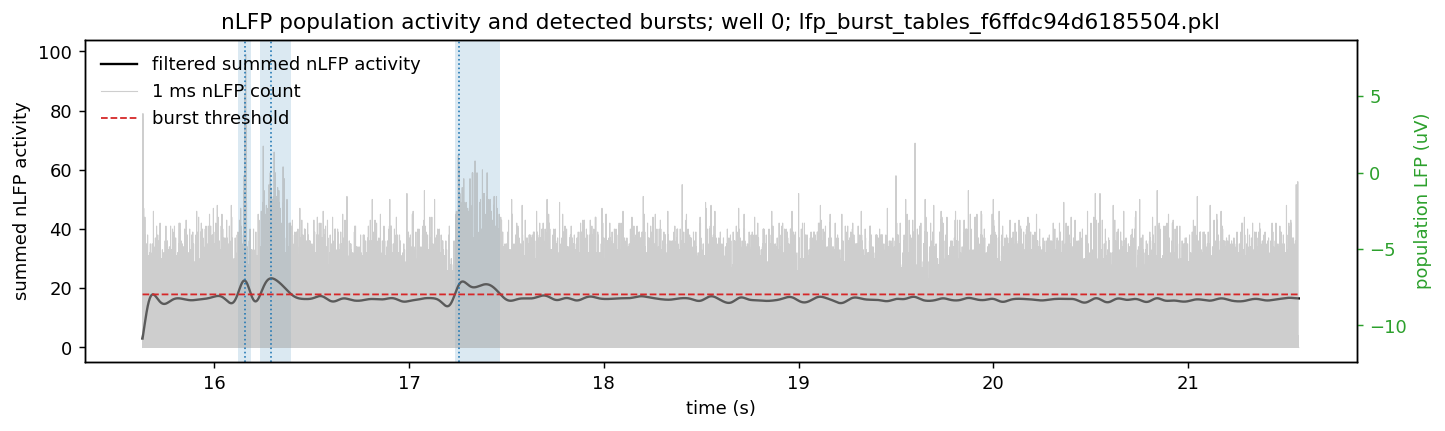

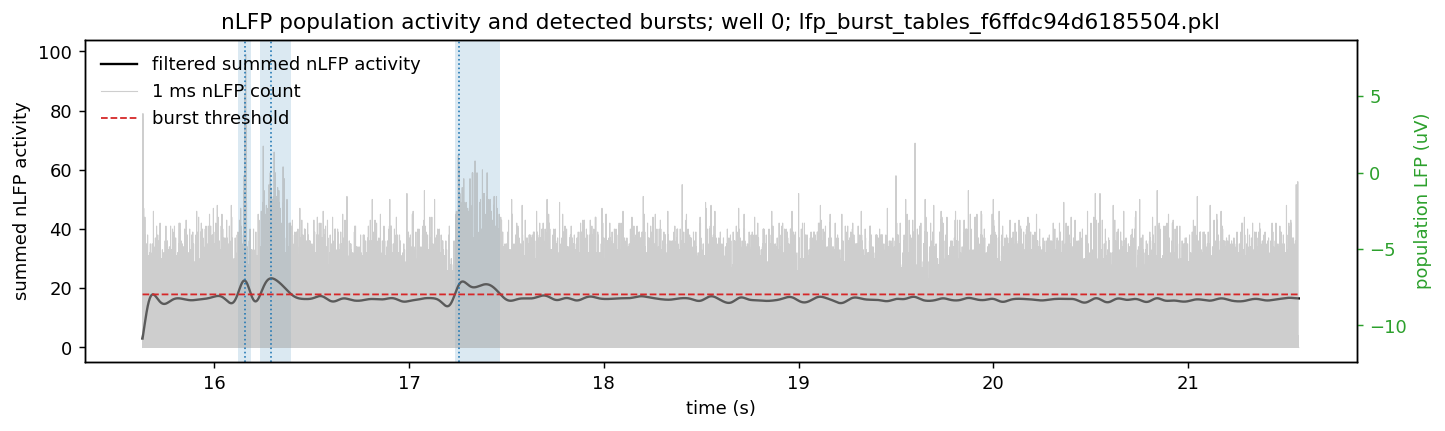

In [135]:
def plot_nlfp_population_activity_diagnostic(event_table, population_trace, *, max_events=8):
    if event_table.empty or population_trace.empty:
        print("No nLFP population diagnostic available for the current cache.")
        return None
    event = event_table.sort_values(["well", "anchor_time_s"]).iloc[0]
    well = int(event["well"])
    trace = population_trace.loc[population_trace["well"].astype(int) == well].copy()
    if trace.empty:
        print(f"No nLFP population trace found for well {well}.")
        return None

    interval_mask = (trace["search_interval_start_s"].astype(float) <= float(event["anchor_time_s"])) & (
        trace["search_interval_stop_s"].astype(float) >= float(event["anchor_time_s"])
    )
    if np.any(interval_mask):
        interval_start = float(trace.loc[interval_mask, "search_interval_start_s"].iloc[0])
        interval_stop = float(trace.loc[interval_mask, "search_interval_stop_s"].iloc[0])
    else:
        interval_start = max(float(START_SEC), float(event["anchor_time_s"]) - 1.0)
        interval_stop = min(float(END_SEC), float(event["anchor_time_s"]) + 1.0)
    plot_trace = trace.loc[(trace["time_s"].astype(float) >= interval_start) & (trace["time_s"].astype(float) <= interval_stop)].copy()
    plot_events = event_table.loc[
        (event_table["well"].astype(int) == well)
        & (event_table["start_time_s"].astype(float) <= interval_stop)
        & (event_table["end_time_s"].astype(float) >= interval_start)
    ].sort_values("anchor_time_s").head(int(max_events))

    fig, ax = plt.subplots(figsize=(11, 3.2), constrained_layout=True)
    t = plot_trace["time_s"].to_numpy(float)
    ax.plot(t, plot_trace["nlfp_population"].to_numpy(float), color="black", lw=1.3, label="filtered summed nLFP activity")
    if "nlfp_count" in plot_trace:
        ax.plot(t, plot_trace["nlfp_count"].to_numpy(float), color="0.65", lw=0.6, alpha=0.55, label="1 ms nLFP count")
    threshold = plot_trace["population_threshold"].to_numpy(float)
    if np.any(np.isfinite(threshold)):
        ax.plot(t, threshold, color="tab:red", lw=1.0, ls="--", label="burst threshold")
    for _, row in plot_events.iterrows():
        ax.axvspan(float(row["start_time_s"]), float(row["end_time_s"]), color="tab:blue", alpha=0.16, linewidth=0)
        ax.axvline(float(row["anchor_time_s"]), color="tab:blue", lw=0.9, ls=":")
    ax.set(
        title=f"nLFP population activity and detected bursts; well {well}; {BURST_TABLE_CACHE_PATH.name}",
        xlabel="time (s)",
        ylabel="summed nLFP activity",
    )
    ax.legend(frameon=False, loc="upper left")

    if "population_lfp_uv" in plot_trace and np.any(np.isfinite(plot_trace["population_lfp_uv"].to_numpy(float))):
        ax2 = ax.twinx()
        ax2.plot(t, plot_trace["population_lfp_uv"].to_numpy(float), color="tab:green", lw=0.9, alpha=0.65, label="population LFP")
        ax2.set_ylabel("population LFP (uV)", color="tab:green")
        ax2.tick_params(axis="y", colors="tab:green")
    figure_dir = OUTPUT_DIR / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "nlfp_population_activity_diagnostic.png", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / f"nlfp_population_activity_diagnostic_{burst_table_cache_key()}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


plot_nlfp_population_activity_diagnostic(event_df, nlfp_population_trace)



In [136]:
def _deterministic_subset(values, max_n):
    values = np.asarray(values)
    if max_n is None or values.size <= int(max_n):
        return values
    pick = np.round(np.linspace(0, values.size - 1, int(max_n))).astype(int)
    return values[pick]


def _select_events_for_well(event_table):
    valid = event_table.sort_values("anchor_time_s").reset_index(drop=True)
    if valid.empty:
        return valid
    if MAX_EVENTS_PER_WELL is None or len(valid) <= int(MAX_EVENTS_PER_WELL):
        return valid
    idx = np.round(np.linspace(0, len(valid) - 1, int(MAX_EVENTS_PER_WELL))).astype(int)
    return valid.iloc[idx].reset_index(drop=True)


def _active_electrodes_for_event(local_group):
    group = local_group.copy()
    if group.empty:
        return np.array([], dtype=int)
    if "total_spikes" in group:
        group = group.sort_values(["total_spikes", "electrode"], ascending=[False, True])
    else:
        group = group.sort_values("electrode")
    electrodes = group["electrode"].drop_duplicates().to_numpy(int)
    return _deterministic_subset(electrodes, MAX_ACTIVE_SITES_PER_EVENT).astype(int)


def _mapping_for_recording(raw_file, dataset):
    _, _, _, mapping = load_chunk(raw_file, dataset, 0, 1)
    return {
        "channel": np.asarray(mapping["channel"], dtype=int),
        "electrode": np.asarray(mapping["electrode"], dtype=int),
        "x_um": np.asarray(mapping["x"], dtype=float),
        "y_um": np.asarray(mapping["y"], dtype=float),
    }


def _channels_for_electrodes(raw_file, dataset, electrodes):
    mapping = _mapping_for_recording(raw_file, dataset)
    frame = pd.DataFrame(mapping)
    requested = pd.DataFrame({"electrode": np.asarray(electrodes, dtype=int)})
    merged = requested.merge(frame, on="electrode", how="inner")
    return merged.drop_duplicates("electrode").reset_index(drop=True)


def _load_lfp_segment(raw_file, dataset, center_s, window_s, electrodes, *, min_channels=2):
    info = inspect_file(raw_file, dataset)
    fs_raw = float(info["fs_raw"])
    recording_stop_s = float(info["raw_shape"][1]) / fs_raw
    half = 0.5 * float(window_s)
    start_s = float(center_s) - half
    stop_s = float(center_s) + half
    if start_s < 0 or stop_s > recording_stop_s:
        return None
    channel_table = _channels_for_electrodes(raw_file, dataset, electrodes)
    if channel_table.empty or len(channel_table) < int(min_channels):
        return None
    start_frame = int(round(start_s * fs_raw))
    n_frames = max(1, int(round((stop_s - start_s) * fs_raw)))
    raw, coords_mm, fs_loaded, mapping = load_chunk(
        raw_file,
        dataset,
        start_frame,
        n_frames,
        channels=channel_table["channel"].to_numpy(int),
    )
    if raw.shape[0] < 8 or raw.shape[1] < int(min_channels):
        return None
    band = bandpass_downsample(
        raw,
        fs_loaded,
        COHERENCE_FILTER_LOW_HZ,
        COHERENCE_FILTER_HIGH_HZ,
        COHERENCE_FS_HZ,
        max_channels_per_block=128,
    )
    electrodes_loaded = np.asarray(mapping["electrode"], dtype=int)
    channels_loaded = np.asarray(mapping["channel"], dtype=int)
    coords_um = np.column_stack([np.asarray(mapping["x"], dtype=float), np.asarray(mapping["y"], dtype=float)])
    t_s = start_s + np.arange(band.shape[0], dtype=float) / float(COHERENCE_FS_HZ)
    return {
        "data": band.astype(np.float32, copy=False),
        "t_s": t_s,
        "coords_um": coords_um,
        "electrodes": electrodes_loaded,
        "channels": channels_loaded,
        "start_s": start_s,
        "stop_s": stop_s,
        "center_s": float(center_s),
        "window_s": float(window_s),
    }


In [137]:
def morlet_coefficients(traces, fs_hz, freqs_hz, *, n_cycles=MORLET_N_CYCLES):
    x = np.asarray(traces, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError("traces must be samples x channels")
    x = x - np.nanmean(x, axis=0, keepdims=True)
    x = np.nan_to_num(x, copy=False)
    coeffs = np.empty((len(freqs_hz), x.shape[0], x.shape[1]), dtype=np.complex64)
    for fi, freq_hz in enumerate(np.asarray(freqs_hz, dtype=float)):
        sigma_t = float(n_cycles) / (2.0 * np.pi * float(freq_hz))
        half_width = max(3, int(np.ceil(4.0 * sigma_t * float(fs_hz))))
        tau = np.arange(-half_width, half_width + 1, dtype=float) / float(fs_hz)
        wavelet = np.exp(2j * np.pi * float(freq_hz) * tau) * np.exp(-(tau ** 2) / (2.0 * sigma_t ** 2))
        wavelet /= np.sqrt(np.sum(np.abs(wavelet) ** 2))
        coeffs[fi] = fftconvolve(x, np.conj(wavelet[::-1, None]), mode="same", axes=0).astype(np.complex64, copy=False)
    return coeffs


def largest_nlfp_reference(data):
    negative_peak = -np.nanmin(np.asarray(data, dtype=float), axis=0)
    if not np.any(np.isfinite(negative_peak)):
        return None
    return int(np.nanargmax(negative_peak))


def _band_frequency_mask(band):
    low, high = map(float, band)
    mask = (WAVELET_FREQS_HZ >= low) & (WAVELET_FREQS_HZ <= high)
    if LINE_NOISE_EXCLUSION_HZ is not None:
        noise_low, noise_high = map(float, LINE_NOISE_EXCLUSION_HZ)
        mask &= ~((WAVELET_FREQS_HZ >= noise_low) & (WAVELET_FREQS_HZ <= noise_high))
    return mask


def _peak_frequency_from_power(coeffs, band, time_mask):
    freq_mask = _band_frequency_mask(band)
    freq_idx = np.flatnonzero(freq_mask)
    if freq_idx.size == 0 or not np.any(time_mask):
        return np.nan
    power = np.nanmean(np.abs(coeffs[freq_idx][:, time_mask, :]) ** 2, axis=(1, 2))
    if not np.any(np.isfinite(power)):
        return np.nan
    return float(WAVELET_FREQS_HZ[int(freq_idx[int(np.nanargmax(power))])])


def wavelet_coherence_time_frequency(coeffs, ref_idx, target_coeffs=None, target_idx=None):
    coeffs = np.asarray(coeffs)
    target_coeffs = coeffs if target_coeffs is None else np.asarray(target_coeffs)
    if coeffs.ndim != 3 or target_coeffs.shape != coeffs.shape:
        raise ValueError("coefficients must have shape frequencies x samples x channels")
    ref_idx = int(ref_idx)
    if target_idx is None:
        target_idx = np.flatnonzero(np.arange(coeffs.shape[2]) != ref_idx)
    else:
        target_idx = np.asarray(target_idx, dtype=int)
    target_idx = target_idx[target_idx != ref_idx]
    if target_idx.size == 0:
        return np.full(coeffs.shape[:2], np.nan, dtype=float)

    ref = coeffs[:, :, ref_idx]
    tgt = target_coeffs[:, :, target_idx]
    cross = np.nanmean(ref[:, :, None] * np.conj(tgt), axis=2)
    ref_power = np.abs(ref) ** 2
    tgt_power = np.nanmean(np.abs(tgt) ** 2, axis=2)
    sigma = (
        float(WAVELET_COHERENCE_SMOOTH_FREQ_BINS),
        max(0.0, float(WAVELET_COHERENCE_SMOOTH_TIME_MS) * 1e-3 * float(COHERENCE_FS_HZ)),
    )
    smooth_cross = gaussian_filter(np.real(cross), sigma=sigma) + 1j * gaussian_filter(np.imag(cross), sigma=sigma)
    smooth_ref = gaussian_filter(ref_power, sigma=sigma)
    smooth_tgt = gaussian_filter(tgt_power, sigma=sigma)
    denom = np.sqrt(np.maximum(smooth_ref * smooth_tgt, np.finfo(float).tiny))
    return np.clip(np.abs(smooth_cross) / denom, 0.0, 1.0)


def average_tf_coherence_map(tf_coh, freq_mask, time_mask):
    freq_idx = np.flatnonzero(freq_mask)
    time_idx = np.flatnonzero(time_mask)
    if freq_idx.size == 0 or time_idx.size < 3:
        return np.nan
    return float(np.nanmean(tf_coh[freq_idx][:, time_idx]))

def _band_site_power(coeffs, band, time_mask):
    freq_mask = _band_frequency_mask(band)
    if not np.any(freq_mask) or not np.any(time_mask):
        return np.full(coeffs.shape[2], np.nan, dtype=float)
    return np.nanmean(np.abs(coeffs[freq_mask][:, time_mask, :]) ** 2, axis=(0, 1))


def _event_condition_rows(segment, *, well, event_idx, anchor_time_s, condition, ref_electrode=None, segment_coeffs=None, target_segment=None, target_coeffs=None, shift_rep=np.nan):
    data = segment["data"]
    if ref_electrode is None:
        ref_idx = largest_nlfp_reference(data)
    else:
        matches = np.flatnonzero(segment["electrodes"] == int(ref_electrode))
        ref_idx = int(matches[0]) if matches.size else None
    if ref_idx is None or data.shape[1] < 2:
        return [], [], [], [], None, {}

    target = segment if target_segment is None else target_segment
    if target["data"].shape != data.shape or not np.array_equal(target["electrodes"], segment["electrodes"]):
        return [], [], [], [], None, {}

    coeffs = segment_coeffs if segment_coeffs is not None else morlet_coefficients(data, COHERENCE_FS_HZ, WAVELET_FREQS_HZ)
    target_coeffs = coeffs if target_coeffs is None and target_segment is None else target_coeffs if target_coeffs is not None else morlet_coefficients(target["data"], COHERENCE_FS_HZ, WAVELET_FREQS_HZ)
    coords = np.asarray(segment["coords_um"], dtype=float)
    ref_coord = coords[ref_idx]
    distance_um = np.sqrt(np.sum((coords - ref_coord[None, :]) ** 2, axis=1))
    not_ref = np.arange(coords.shape[0]) != ref_idx
    edges, centers = distance_edges_and_centers()
    bin_idx = np.searchsorted(edges, distance_um, side="right") - 1
    keep_site = not_ref & (bin_idx >= 0) & (bin_idx < centers.size) & np.isfinite(distance_um)
    time_mask = np.ones(data.shape[0], dtype=bool)
    rows = []
    site_rows = []
    spectrum_rows = []
    power_rows = []
    peak_specs = {}

    for band_name, band in FREQUENCY_BANDS.items():
        freq_mask = _band_frequency_mask(band)
        peak_frequency_hz = _peak_frequency_from_power(coeffs, band, time_mask)
        peak_specs[band_name] = {"peak_frequency_hz": peak_frequency_hz}
        keep = keep_site.copy()
        for b in np.unique(bin_idx[keep]):
            target_indices = np.flatnonzero(keep & (bin_idx == b))
            if target_indices.size == 0:
                continue
            tf_bin = wavelet_coherence_time_frequency(
                coeffs, ref_idx, target_coeffs=target_coeffs, target_idx=target_indices
            )
            coherence_value = average_tf_coherence_map(tf_bin, freq_mask, time_mask)
            if not np.isfinite(coherence_value):
                continue
            rows.append({
                "well": int(well),
                "event_idx": int(event_idx),
                "condition": str(condition),
                "shift_rep": shift_rep,
                "band": str(band_name),
                "distance_bin_idx": int(b),
                "distance_bin_center_um": float(centers[int(b)]),
                "coherence": coherence_value,
                "n_sites": int(target_indices.size),
                "ref_electrode": int(segment["electrodes"][ref_idx]),
                "anchor_time_s": float(anchor_time_s),
                "segment_start_s": float(segment["start_s"]),
                "segment_stop_s": float(segment["stop_s"]),
                "target_start_s": float(target["start_s"]),
                "target_stop_s": float(target["stop_s"]),
                "peak_frequency_hz": peak_frequency_hz,
                "window_duration_s": float(segment["window_s"]),
            })
        if STORE_SITE_ROWS:
            for idx in np.flatnonzero(keep):
                tf_site = wavelet_coherence_time_frequency(
                    coeffs, ref_idx, target_coeffs=target_coeffs, target_idx=[idx]
                )
                site_value = average_tf_coherence_map(tf_site, freq_mask, time_mask)
                if not np.isfinite(site_value):
                    continue
                site_rows.append({
                    "well": int(well),
                    "event_idx": int(event_idx),
                    "condition": str(condition),
                    "shift_rep": shift_rep,
                    "band": str(band_name),
                    "distance_um": float(distance_um[idx]),
                    "distance_bin_idx": int(bin_idx[idx]),
                    "distance_bin_center_um": float(centers[int(bin_idx[idx])]),
                    "coherence": site_value,
                    "ref_electrode": int(segment["electrodes"][ref_idx]),
                    "target_electrode": int(segment["electrodes"][idx]),
                    "peak_frequency_hz": peak_frequency_hz,
                })
        if band_name == "gamma" and condition == "burst":
            gamma_power = _band_site_power(coeffs, band, time_mask)
            order = np.argsort(np.nan_to_num(gamma_power, nan=-np.inf))[::-1]
            ranks = np.empty_like(order)
            ranks[order] = np.arange(1, order.size + 1)
            for idx, power in enumerate(gamma_power):
                if not np.isfinite(power):
                    continue
                power_rows.append({
                    "well": int(well),
                    "event_idx": int(event_idx),
                    "condition": str(condition),
                    "electrode": int(segment["electrodes"][idx]),
                    "x_um": float(coords[idx, 0]),
                    "y_um": float(coords[idx, 1]),
                    "distance_um": float(distance_um[idx]),
                    "gamma_power": float(power),
                    "gamma_power_rank": int(ranks[idx]),
                    "is_ref_electrode": bool(idx == ref_idx),
                    "ref_electrode": int(segment["electrodes"][ref_idx]),
                    "peak_frequency_hz": peak_frequency_hz,
                })

    if np.any(keep_site):
        time_idx = np.flatnonzero(time_mask)
        target_indices = np.flatnonzero(keep_site)
        tf_all = wavelet_coherence_time_frequency(
            coeffs, ref_idx, target_coeffs=target_coeffs, target_idx=target_indices
        )
        for freq_idx, freq_hz in enumerate(WAVELET_FREQS_HZ):
            if LINE_NOISE_EXCLUSION_HZ is not None:
                noise_low, noise_high = map(float, LINE_NOISE_EXCLUSION_HZ)
                if noise_low <= float(freq_hz) <= noise_high:
                    continue
            vals = tf_all[int(freq_idx), time_idx]
            vals = vals[np.isfinite(vals)]
            if vals.size:
                spectrum_rows.append({
                    "well": int(well),
                    "event_idx": int(event_idx),
                    "condition": str(condition),
                    "shift_rep": shift_rep,
                    "frequency_hz": float(freq_hz),
                    "coherence": float(np.nanmean(vals)),
                    "n_sites": int(target_indices.size),
                    "ref_electrode": int(segment["electrodes"][ref_idx]),
                    "anchor_time_s": float(anchor_time_s),
                })

    return rows, site_rows, spectrum_rows, power_rows, int(segment["electrodes"][ref_idx]), peak_specs


def _random_shift_center(anchor_s, window_s, recording_stop_s, rng):
    half = 0.5 * float(window_s)
    for _ in range(100):
        shift = rng.uniform(-float(BACKGROUND_SHIFT_MAX_S), float(BACKGROUND_SHIFT_MAX_S))
        if abs(shift) < float(window_s):
            continue
        center = float(anchor_s) + float(shift)
        if center - half >= 0 and center + half <= float(recording_stop_s):
            return center
    return np.nan


def _segment_shifted_target_coeffs(raw_file, dataset, anchor_s, window_s, burst_segment, rng):
    info = inspect_file(raw_file, dataset)
    recording_stop_s = float(info["raw_shape"][1]) / float(info["fs_raw"])
    center = _random_shift_center(anchor_s, window_s, recording_stop_s, rng)
    if not np.isfinite(center):
        return None, np.nan
    shifted = _load_lfp_segment(
        raw_file,
        dataset,
        center,
        window_s,
        np.asarray(burst_segment["electrodes"], dtype=int),
        min_channels=2,
    )
    if shifted is None or shifted["data"].shape != burst_segment["data"].shape:
        return None, np.nan
    if not np.array_equal(shifted["electrodes"], burst_segment["electrodes"]):
        return None, np.nan
    return morlet_coefficients(shifted["data"], COHERENCE_FS_HZ, WAVELET_FREQS_HZ), float(center)


def _independent_shifted_target_coeffs(raw_file, dataset, anchor_s, window_s, burst_segment, ref_idx, rng):
    info = inspect_file(raw_file, dataset)
    recording_stop_s = float(info["raw_shape"][1]) / float(info["fs_raw"])
    n_freq = len(WAVELET_FREQS_HZ)
    n_time, n_channels = burst_segment["data"].shape
    target_coeffs = np.full((n_freq, n_time, n_channels), np.nan + 0j, dtype=np.complex64)
    shift_centers = np.full(n_channels, np.nan, dtype=float)
    target_coeffs[:, :, int(ref_idx)] = morlet_coefficients(
        burst_segment["data"][:, [int(ref_idx)]], COHERENCE_FS_HZ, WAVELET_FREQS_HZ
    )[:, :, 0]
    for idx, electrode in enumerate(np.asarray(burst_segment["electrodes"], dtype=int)):
        if idx == int(ref_idx):
            continue
        center = _random_shift_center(anchor_s, window_s, recording_stop_s, rng)
        if not np.isfinite(center):
            continue
        shifted = _load_lfp_segment(raw_file, dataset, center, window_s, [int(electrode)], min_channels=1)
        if shifted is None or shifted["data"].shape[0] != n_time:
            continue
        target_coeffs[:, :, idx] = morlet_coefficients(shifted["data"], COHERENCE_FS_HZ, WAVELET_FREQS_HZ)[:, :, 0]
        shift_centers[idx] = center
    return target_coeffs, shift_centers


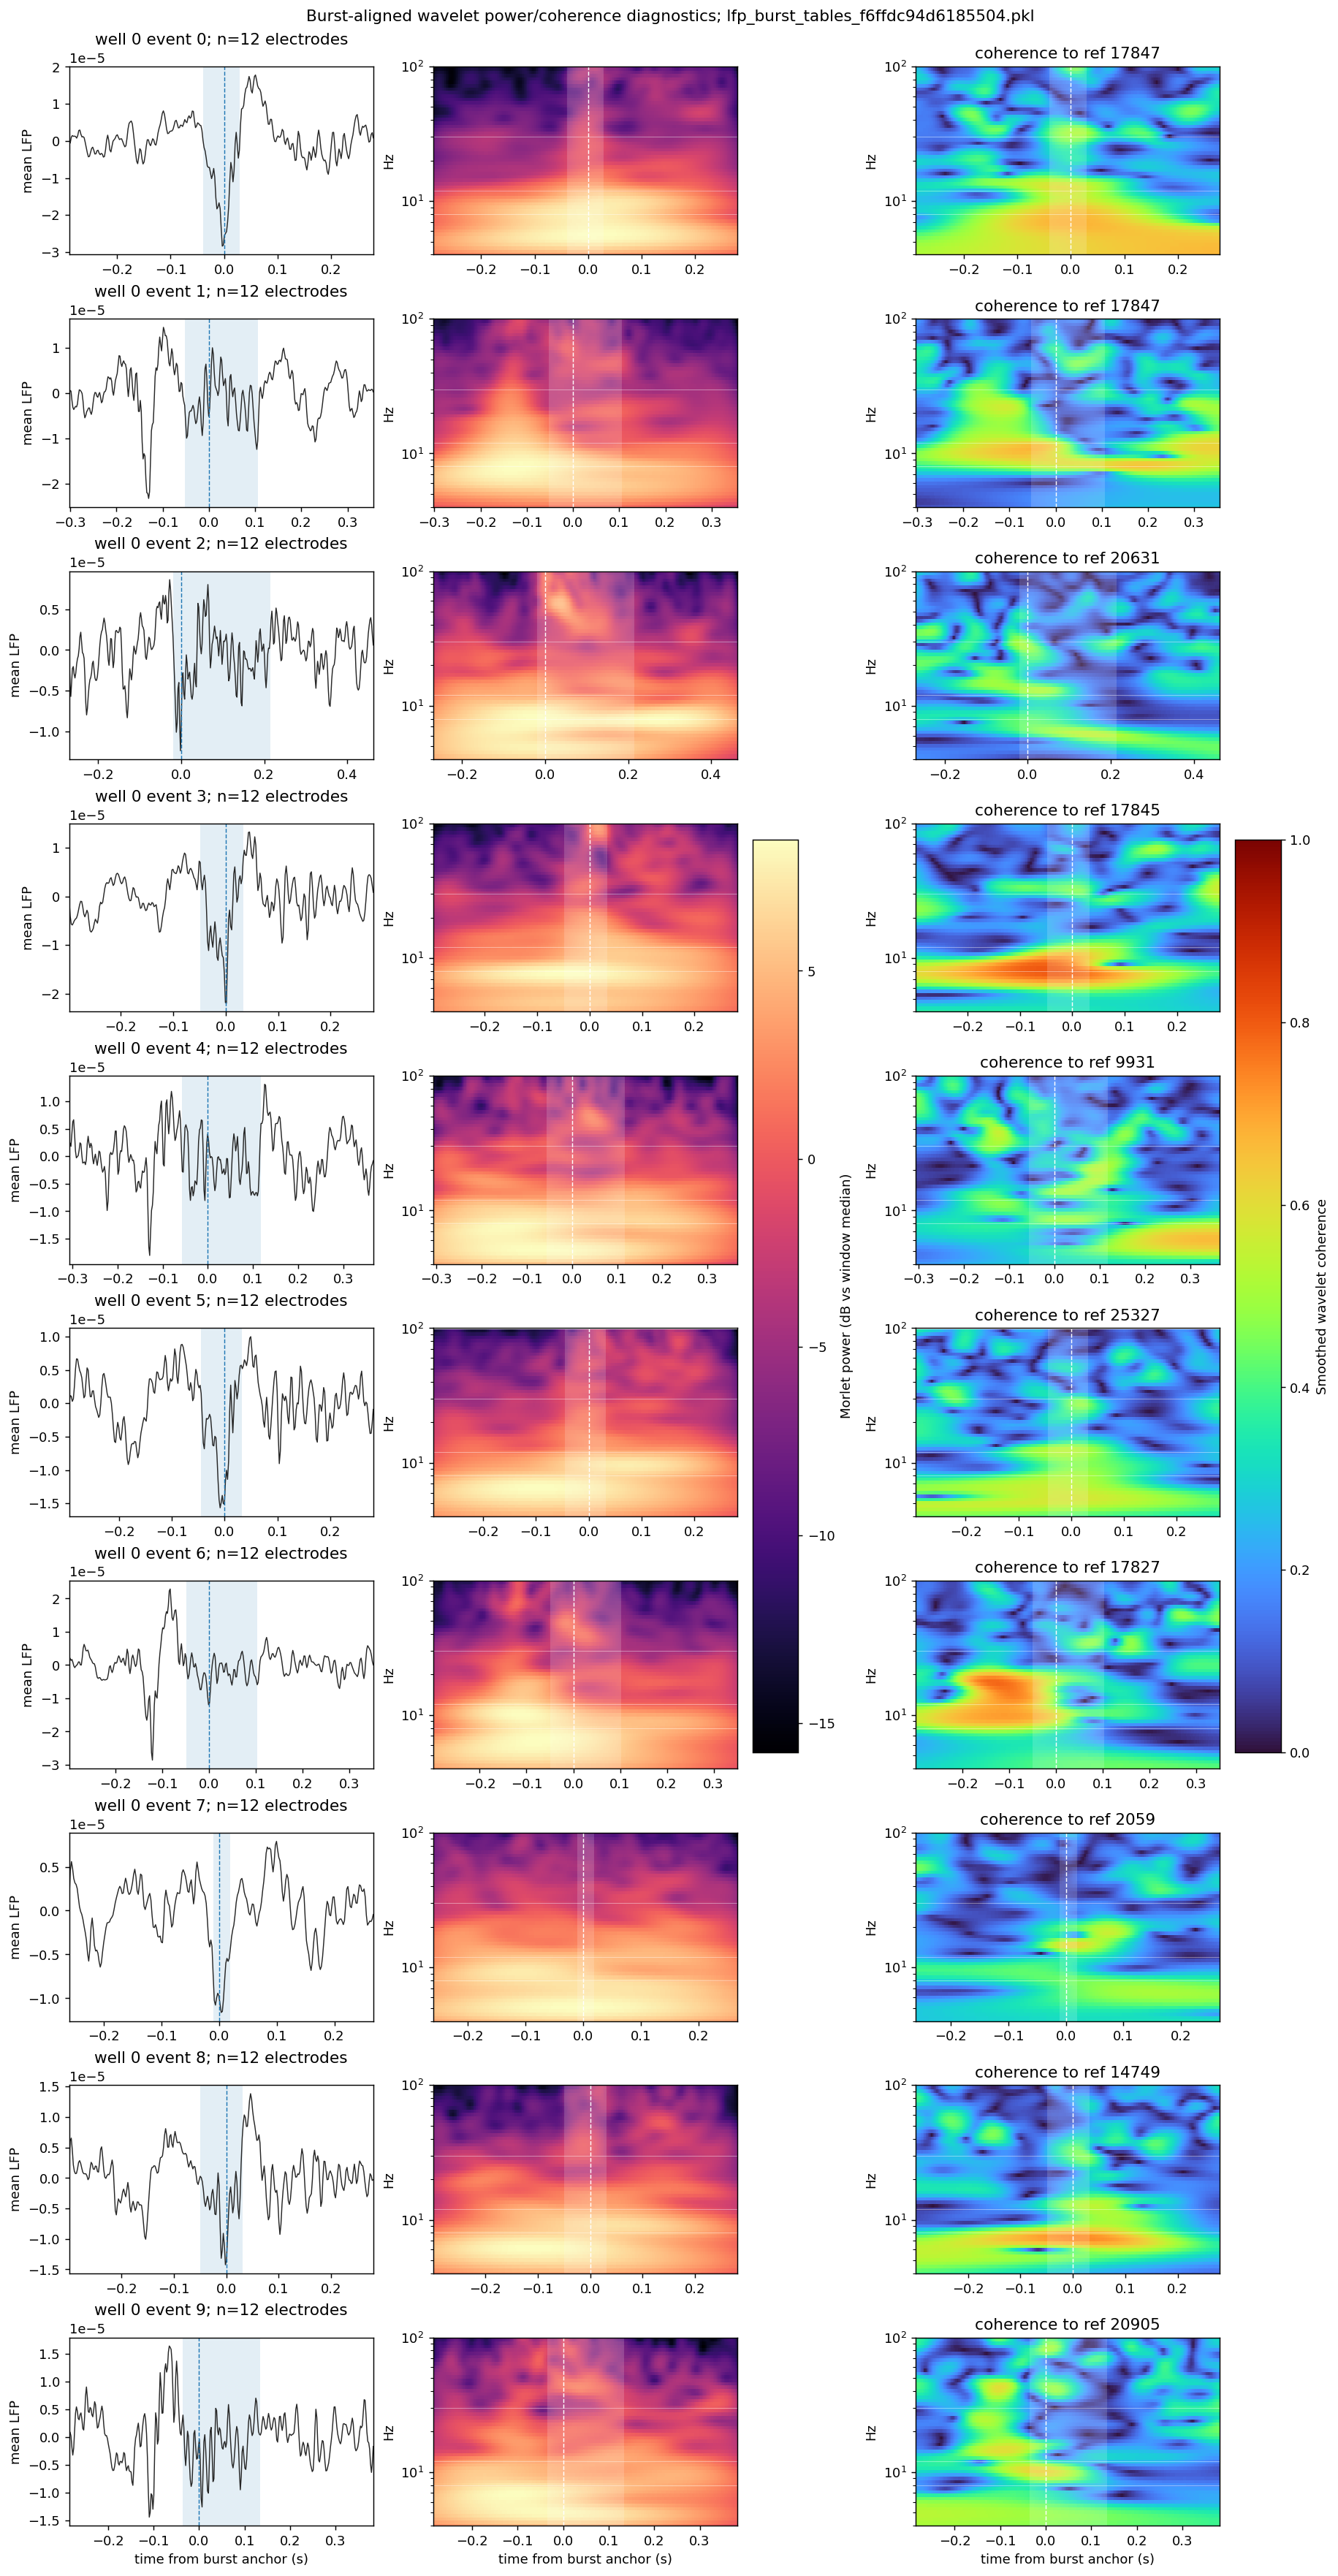

In [138]:
def _spectrogram_event_specs(event_table, local_table, max_events=SPECTROGRAM_N_EVENTS):
    if event_table.empty or local_table.empty or int(max_events) <= 0:
        return []
    events = event_table.sort_values(["well", "anchor_time_s"]).copy()
    specs = []
    for _, event in events.iterrows():
        local = local_table.loc[
            (local_table["well"].astype(int) == int(event["well"]))
            & (local_table["event_idx"].astype(int) == int(event["event_idx"]))
        ]
        electrodes = _active_electrodes_for_event(local)
        if electrodes.size < 2:
            continue
        specs.append((event, electrodes[: int(SPECTROGRAM_N_ELECTRODES)]))
        if len(specs) >= int(max_events):
            break
    return specs


def build_burst_wavelet_spectrogram_diagnostics(event_table, local_table):
    rows = []
    for event, electrodes in _spectrogram_event_specs(event_table, local_table):
        start_s = max(float(START_SEC), float(event["coherence_start_s"]) - float(SPECTROGRAM_PAD_S))
        stop_s = min(float(END_SEC), float(event["coherence_stop_s"]) + float(SPECTROGRAM_PAD_S))
        if stop_s <= start_s:
            continue
        center_s = 0.5 * (start_s + stop_s)
        segment = _load_lfp_segment(
            Path(event["raw_file"]),
            str(event["dataset"]),
            center_s,
            stop_s - start_s,
            electrodes,
            min_channels=2,
        )
        if segment is None:
            continue
        coeffs = morlet_coefficients(segment["data"], COHERENCE_FS_HZ, WAVELET_FREQS_HZ)
        power = np.nanmean(np.abs(coeffs) ** 2, axis=2)
        baseline = np.nanmedian(power)
        power_db = 10.0 * np.log10(np.maximum(power, np.finfo(float).tiny) / max(float(baseline), np.finfo(float).tiny))
        ref_idx = largest_nlfp_reference(segment["data"])
        coherence_tf = wavelet_coherence_time_frequency(coeffs, ref_idx) if ref_idx is not None else np.full(power.shape, np.nan)
        trace = np.nanmean(segment["data"], axis=1)
        rows.append({
            "well": int(event["well"]),
            "event_idx": int(event["event_idx"]),
            "anchor_time_s": float(event["anchor_time_s"]),
            "burst_start_rel_s": float(event["coherence_start_s"] - event["anchor_time_s"]),
            "burst_stop_rel_s": float(event["coherence_stop_s"] - event["anchor_time_s"]),
            "time_rel_s": np.asarray(segment["t_s"], dtype=float) - float(event["anchor_time_s"]),
            "freq_hz": np.asarray(WAVELET_FREQS_HZ, dtype=float),
            "power_db": power_db,
            "coherence_tf": coherence_tf,
            "ref_electrode": int(segment["electrodes"][ref_idx]) if ref_idx is not None else -1,
            "mean_trace_uv": trace,
            "n_electrodes": int(segment["data"].shape[1]),
        })
    return rows


spectrogram_diagnostics = build_burst_wavelet_spectrogram_diagnostics(event_df, local_df)
if spectrogram_diagnostics:
    n_rows = len(spectrogram_diagnostics)
    fig, axes = plt.subplots(n_rows, 3, figsize=(14, 2.7 * n_rows), constrained_layout=True, sharex=False)
    if n_rows == 1:
        axes = np.asarray([axes])
    image = None
    for row_idx, diag in enumerate(spectrogram_diagnostics):
        ax_trace, ax_power, ax_coh = axes[row_idx]
        t = diag["time_rel_s"]
        ax_trace.plot(t, diag["mean_trace_uv"], color="0.15", lw=0.8)
        ax_trace.axvspan(diag["burst_start_rel_s"], diag["burst_stop_rel_s"], color="tab:blue", alpha=0.12, linewidth=0)
        ax_trace.axvline(0.0, color="tab:blue", lw=0.8, ls="--")
        ax_trace.set(title=f"well {diag['well']} event {diag['event_idx']}; n={diag['n_electrodes']} electrodes", ylabel="mean LFP")
        ax_trace.set_xlim(t[0], t[-1])

        image = ax_power.pcolormesh(t, diag["freq_hz"], diag["power_db"], shading="auto", cmap="magma")
        ax_power.axvspan(diag["burst_start_rel_s"], diag["burst_stop_rel_s"], color="white", alpha=0.16, linewidth=0)
        ax_power.axvline(0.0, color="white", lw=0.8, ls="--")
        for boundary_hz in (8.0, 12.0, 30.0):
            ax_power.axhline(boundary_hz, color="white", lw=0.5, alpha=0.45)
        ax_power.set_yscale("log")
        ax_power.set_ylim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
        ax_power.set(ylabel="Hz")
        ax_power.set_xlim(t[0], t[-1])

        coh_image = ax_coh.pcolormesh(t, diag["freq_hz"], diag["coherence_tf"], shading="auto", cmap="turbo", vmin=0.0, vmax=1.0)
        ax_coh.axvspan(diag["burst_start_rel_s"], diag["burst_stop_rel_s"], color="white", alpha=0.16, linewidth=0)
        ax_coh.axvline(0.0, color="white", lw=0.8, ls="--")
        for boundary_hz in (8.0, 12.0, 30.0):
            ax_coh.axhline(boundary_hz, color="white", lw=0.5, alpha=0.45)
        ax_coh.set_yscale("log")
        ax_coh.set_ylim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
        ax_coh.set(ylabel="Hz", title=f"coherence to ref {diag['ref_electrode']}")
        ax_coh.set_xlim(t[0], t[-1])
    axes[-1, 0].set_xlabel("time from burst anchor (s)")
    axes[-1, 1].set_xlabel("time from burst anchor (s)")
    axes[-1, 2].set_xlabel("time from burst anchor (s)")
    if image is not None:
        fig.colorbar(image, ax=axes[:, 1], shrink=0.9, label="Morlet power (dB vs window median)")
        fig.colorbar(coh_image, ax=axes[:, 2], shrink=0.9, label="Smoothed wavelet coherence")
    fig.suptitle(f"Burst-aligned wavelet power/coherence diagnostics; {BURST_TABLE_CACHE_PATH.name}")
    figure_dir = OUTPUT_DIR / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "morlet_burst_window_spectrogram_diagnostic.png", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / "morlet_burst_window_spectrogram_diagnostic.pdf", bbox_inches="tight")
    fig.savefig(figure_dir / f"morlet_burst_window_spectrogram_diagnostic_{burst_table_cache_key()}.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No burst spectrogram diagnostics could be built with the current event/electrode limits.")


In [139]:


def compute_wavelet_distance_coherence(event_df, local_df):
    distance_rows = []
    site_rows = []
    spectrum_rows = []
    gamma_power_rows = []
    selected_events = []
    if event_df.empty or local_df.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    rng = np.random.default_rng(int(BACKGROUND_RANDOM_SEED))
    for well, well_events in event_df.groupby("well", sort=True):
        well_selected = _select_events_for_well(well_events)
        local_well = local_df.loc[local_df["well"] == int(well)]
        for _, event in well_selected.iterrows():
            event_idx = int(event["event_idx"])
            local_group = local_well.loc[local_well["event_idx"] == event_idx]
            electrodes = _active_electrodes_for_event(local_group)
            if electrodes.size < 2:
                continue
            raw_file = str(event["raw_file"])
            dataset = str(event["dataset"])
            anchor_s = float(event["anchor_time_s"])
            window_s = float(event["coherence_window_s"])
            center_s = 0.5 * (float(event["coherence_start_s"]) + float(event["coherence_stop_s"]))

            burst_segment = _load_lfp_segment(raw_file, dataset, center_s, window_s, electrodes)
            if burst_segment is None:
                continue
            burst_coeffs = morlet_coefficients(burst_segment["data"], COHERENCE_FS_HZ, WAVELET_FREQS_HZ)
            burst_rows, burst_site_rows, burst_spectrum, burst_gamma_power, ref_electrode, peak_specs = _event_condition_rows(
                burst_segment,
                well=well,
                event_idx=event_idx,
                anchor_time_s=anchor_s,
                condition="burst",
                segment_coeffs=burst_coeffs,
            )
            if ref_electrode is None:
                continue
            distance_rows.extend(burst_rows)
            site_rows.extend(burst_site_rows)
            spectrum_rows.extend(burst_spectrum)
            gamma_power_rows.extend(burst_gamma_power)

            ref_idx = int(np.flatnonzero(burst_segment["electrodes"] == int(ref_electrode))[0])
            for shift_rep in range(1, int(BACKGROUND_SHIFT_REPS) + 1):
                if BACKGROUND_SHIFT_MODE == "independent":
                    shifted_coeffs, _ = _independent_shifted_target_coeffs(
                        raw_file, dataset, anchor_s, window_s, burst_segment, ref_idx, rng
                    )
                else:
                    shifted_coeffs, _ = _segment_shifted_target_coeffs(
                        raw_file, dataset, anchor_s, window_s, burst_segment, rng
                    )
                if shifted_coeffs is None:
                    continue
                shifted_rows, shifted_site_rows, shifted_spectrum, _, _, _ = _event_condition_rows(
                    burst_segment,
                    well=well,
                    event_idx=event_idx,
                    anchor_time_s=anchor_s,
                    condition="shifted",
                    ref_electrode=ref_electrode,
                    segment_coeffs=burst_coeffs,
                    target_coeffs=shifted_coeffs,
                    shift_rep=shift_rep,
                )
                distance_rows.extend(shifted_rows)
                site_rows.extend(shifted_site_rows)
                spectrum_rows.extend(shifted_spectrum)

            selected_events.append({
                "well": int(well),
                "event_idx": event_idx,
                "anchor_time_s": anchor_s,
                "raw_file": raw_file,
                "dataset": dataset,
                "n_active_electrodes": int(electrodes.size),
                "ref_electrode": int(ref_electrode),
                "window_duration_s": window_s,
                "theta_peak_frequency_hz": peak_specs.get("theta", {}).get("peak_frequency_hz", np.nan),
                "beta_peak_frequency_hz": peak_specs.get("beta", {}).get("peak_frequency_hz", np.nan),
                "gamma_peak_frequency_hz": peak_specs.get("gamma", {}).get("peak_frequency_hz", np.nan),
            })
        print(f"well {well}: processed {len([r for r in selected_events if r['well'] == int(well)])} events")

    return (
        pd.DataFrame(distance_rows),
        pd.DataFrame(site_rows),
        pd.DataFrame(spectrum_rows),
        pd.DataFrame(gamma_power_rows),
        pd.DataFrame(selected_events),
    )


if ANALYSIS_CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with ANALYSIS_CACHE_PATH.open("rb") as f:
        cached = pickle.load(f)
    event_distance_coherence = cached["event_distance_coherence"]
    lfp_site_coherence = cached.get("lfp_site_coherence", pd.DataFrame())
    frequency_coherence = cached.get("frequency_coherence", pd.DataFrame())
    gamma_site_power = cached.get("gamma_site_power", pd.DataFrame())
    selected_event_table = cached.get("selected_event_table", pd.DataFrame())
    print(f"Loaded cached Morlet LFP coherence: {ANALYSIS_CACHE_PATH}")
else:
    event_distance_coherence, lfp_site_coherence, frequency_coherence, gamma_site_power, selected_event_table = compute_wavelet_distance_coherence(event_df, local_df)
    with ANALYSIS_CACHE_PATH.open("wb") as f:
        pickle.dump({
            "event_distance_coherence": event_distance_coherence,
            "lfp_site_coherence": lfp_site_coherence,
            "frequency_coherence": frequency_coherence,
            "gamma_site_power": gamma_site_power,
            "selected_event_table": selected_event_table,
            "cache_summary": cache_summary,
        }, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Wrote Morlet LFP coherence cache: {ANALYSIS_CACHE_PATH}")

print("event_distance_coherence", event_distance_coherence.shape)
print("frequency_coherence", frequency_coherence.shape)
print("gamma_site_power", gamma_site_power.shape)
print("selected events", selected_event_table.shape)
display(event_distance_coherence.head())
display(selected_event_table.head())


well 0: processed 10 events
well 1: processed 10 events
Wrote Morlet LFP coherence cache: /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance/lfp_morlet_site_coherence_0ac887a799bc074e.pkl
event_distance_coherence (3498, 17)
frequency_coherence (2200, 9)
gamma_site_power (2000, 12)
selected events (20, 11)


,well,event_idx,condition,shift_rep,band,distance_bin_idx,distance_bin_center_um,coherence,n_sites,ref_electrode,anchor_time_s,segment_start_s,segment_stop_s,target_start_s,target_stop_s,peak_frequency_hz,window_duration_s
0,0,0,burst,NaN,theta,0,100.0,0.998918,1,17847,16.1585,16.119,16.188,16.119,16.188,7.550995,0.069
1,0,0,burst,NaN,theta,1,200.0,0.081557,4,17847,16.1585,16.119,16.188,16.119,16.188,7.550995,0.069
2,0,0,burst,NaN,theta,2,300.0,0.584079,5,17847,16.1585,16.119,16.188,16.119,16.188,7.550995,0.069
3,0,0,burst,NaN,theta,3,400.0,0.538204,5,17847,16.1585,16.119,16.188,16.119,16.188,7.550995,0.069
4,0,0,burst,NaN,theta,4,500.0,0.621414,5,17847,16.1585,16.119,16.188,16.119,16.188,7.550995,0.069


,well,event_idx,anchor_time_s,raw_file,dataset,n_active_electrodes,ref_electrode,window_duration_s,theta_peak_frequency_hz,beta_peak_frequency_hz,gamma_peak_frequency_hz
0,0,0,16.1585,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0000,100,17847,0.069,7.550995,15.101989,30.203978
1,0,8,82.5095,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0000,100,4647,0.081,7.550995,12.699208,30.203978
2,0,16,151.7495,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0000,100,7015,0.158,7.550995,12.699208,42.714875
3,0,23,194.6415,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0000,100,9031,0.183,6.727171,12.699208,50.796834
4,0,31,258.1765,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0000,100,23269,0.174,7.550995,12.699208,30.203978


## Summaries

In [140]:
def bootstrap_ci(values, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED, statistic=np.nanmean):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(int(seed))
    boot = np.array([statistic(rng.choice(values, size=values.size, replace=True)) for _ in range(int(reps))])
    return tuple(np.nanpercentile(boot, [2.5, 50.0, 97.5]))


def summarize_condition_distance(event_distance):
    rows = []
    group_cols = ["condition", "band", "well", "distance_bin_center_um"]
    if event_distance.empty or any(col not in event_distance.columns for col in group_cols):
        return pd.DataFrame()
    for key, group in event_distance.groupby(group_cols, sort=True):
        condition, band, well, distance = key
        lo, med, hi = bootstrap_ci(group["coherence"].to_numpy(float), seed=BOOTSTRAP_SEED + int(well))
        rows.append({
            "condition": condition,
            "band": band,
            "well": int(well),
            "distance_bin_center_um": float(distance),
            "coherence_mean": float(np.nanmean(group["coherence"])),
            "coherence_median": float(np.nanmedian(group["coherence"])),
            "coherence_ci_low": lo,
            "coherence_ci_high": hi,
            "n_events": int(group[["well", "event_idx"]].drop_duplicates().shape[0]),
            "n_sites_total": int(group["n_sites"].sum()),
        })
    return pd.DataFrame(rows)


def compute_relative_event_distance(event_distance):
    key = ["well", "event_idx", "band", "distance_bin_center_um"]
    if event_distance.empty or any(col not in event_distance.columns for col in key + ["condition", "coherence"]):
        return pd.DataFrame()
    pivot = event_distance.pivot_table(index=key, columns="condition", values="coherence", aggfunc="mean").reset_index()
    if "burst" not in pivot or "shifted" not in pivot:
        return pd.DataFrame()
    pivot = pivot[np.isfinite(pivot["burst"]) & np.isfinite(pivot["shifted"]) & (pivot["shifted"] > 0)].copy()
    pivot["coherence_relative"] = pivot["burst"] / pivot["shifted"]
    return pivot


def hierarchical_relative_summary(relative_df):
    rows = []
    if relative_df.empty:
        return pd.DataFrame()
    rng = np.random.default_rng(int(BOOTSTRAP_SEED) + 2000)
    wells = np.asarray(sorted(relative_df["well"].unique()), dtype=int)
    for (band, distance), group in relative_df.groupby(["band", "distance_bin_center_um"], sort=True):
        observed = group.groupby("well")["coherence_relative"].mean().mean()
        boot = []
        for _ in range(int(BOOTSTRAP_REPS)):
            sampled_wells = rng.choice(wells, size=wells.size, replace=True)
            sampled_values = []
            for well in sampled_wells:
                values = group.loc[group["well"] == well, "coherence_relative"].to_numpy(float)
                values = values[np.isfinite(values)]
                if values.size:
                    sampled_values.append(np.nanmean(rng.choice(values, size=values.size, replace=True)))
            if sampled_values:
                boot.append(np.nanmean(sampled_values))
        lo, med, hi = np.nanpercentile(boot, [2.5, 50.0, 97.5]) if boot else (np.nan, np.nan, np.nan)
        rows.append({
            "band": str(band),
            "distance_bin_center_um": float(distance),
            "coherence_relative_mean": float(observed),
            "coherence_relative_bootstrap_median": float(med),
            "coherence_relative_ci_low": float(lo),
            "coherence_relative_ci_high": float(hi),
            "n_wells": int(group["well"].nunique()),
            "n_events": int(group[["well", "event_idx"]].drop_duplicates().shape[0]),
        })
    return pd.DataFrame(rows)


def summarize_frequency_coherence(freq_df):
    if freq_df.empty or any(col not in freq_df.columns for col in ["condition", "frequency_hz", "coherence"]):
        return pd.DataFrame()
    rows = []
    for (condition, frequency), group in freq_df.groupby(["condition", "frequency_hz"], sort=True):
        rows.append({
            "condition": condition,
            "frequency_hz": float(frequency),
            "coherence_mean": float(np.nanmean(group["coherence"])),
            "coherence_median": float(np.nanmedian(group["coherence"])),
            "n_events": int(group[["well", "event_idx"]].drop_duplicates().shape[0]),
        })
    return pd.DataFrame(rows)


condition_distance_summary = summarize_condition_distance(event_distance_coherence)
relative_event_distance = compute_relative_event_distance(event_distance_coherence)
relative_distance_summary = hierarchical_relative_summary(relative_event_distance)
frequency_summary = summarize_frequency_coherence(frequency_coherence)

display(condition_distance_summary.head())
display(relative_distance_summary.head())
display(frequency_summary.head())


,condition,band,well,distance_bin_center_um,coherence_mean,coherence_median,coherence_ci_low,coherence_ci_high,n_events,n_sites_total
0,burst,beta,0,100.0,0.777582,0.703989,0.678274,0.874975,9,13
1,burst,beta,0,200.0,0.614191,0.591934,0.467114,0.763521,8,22
2,burst,beta,0,300.0,0.686579,0.663360,0.564381,0.803274,9,20
3,burst,beta,0,400.0,0.382825,0.390028,0.322642,0.450084,10,47
4,burst,beta,0,500.0,0.548042,0.536087,0.454360,0.644742,9,40


,band,distance_bin_center_um,coherence_relative_mean,coherence_relative_bootstrap_median,coherence_relative_ci_low,coherence_relative_ci_high,n_wells,n_events
0,beta,100.0,1.055225,1.054430,0.948142,1.241506,2,13
1,beta,200.0,1.117481,1.070368,0.901692,1.534203,2,16
2,beta,300.0,1.076714,1.057215,0.925234,1.256603,2,19
3,beta,400.0,1.153721,1.163172,0.916509,1.373138,2,20
4,beta,500.0,1.392122,1.389382,1.163129,1.688869,2,19


,condition,frequency_hz,coherence_mean,coherence_median,n_events
0,burst,4.000000,0.159962,0.136729,20
1,burst,4.237852,0.160840,0.139121,20
2,burst,4.489848,0.162099,0.145034,20
3,burst,4.756828,0.163149,0.151741,20
4,burst,5.039684,0.163755,0.153556,20


## Plots

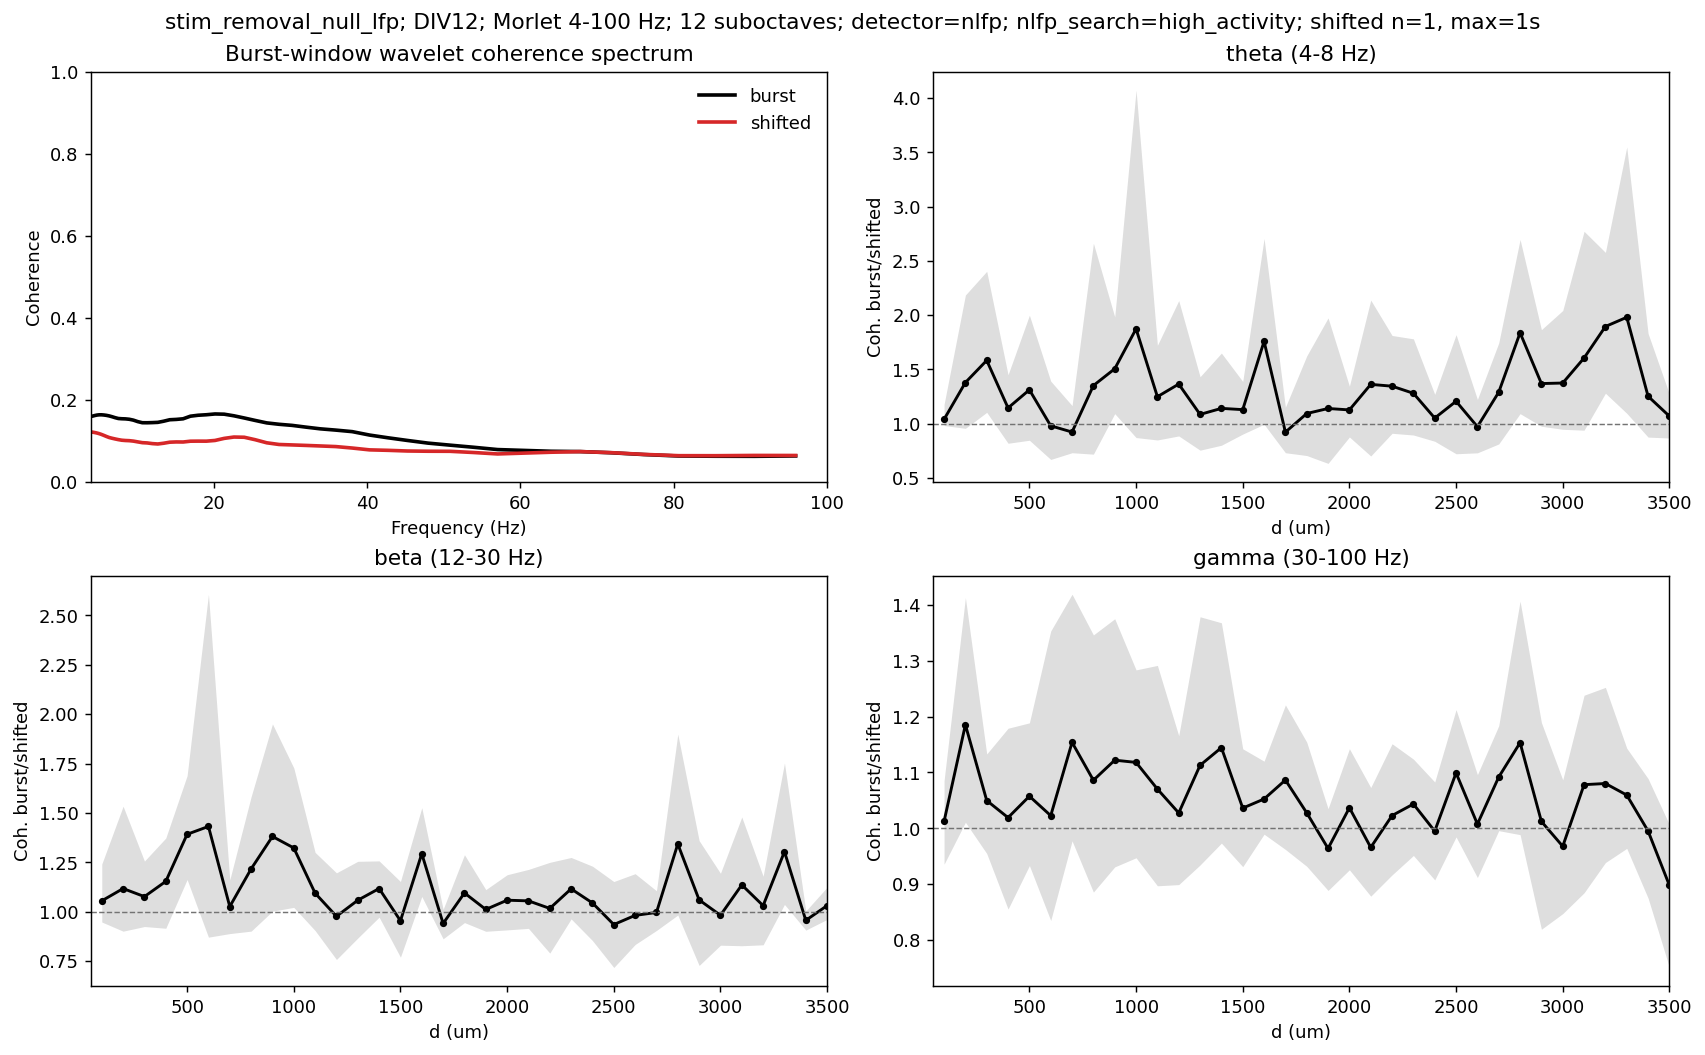

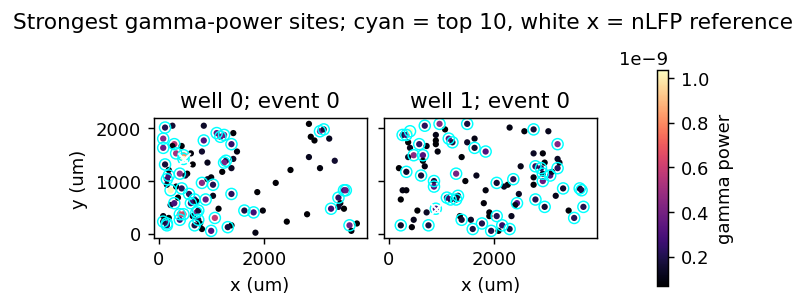

In [141]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

ax = axes[0, 0]
if not frequency_summary.empty:
    for condition, group in frequency_summary.groupby("condition"):
        color = "black" if condition == "burst" else "tab:red"
        ax.plot(group["frequency_hz"], group["coherence_mean"], color=color, lw=2.0, label=condition)
ax.set(title="Burst-window wavelet coherence spectrum", xlabel="Frequency (Hz)", ylabel="Coherence")
ax.set_xlim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
ax.set_ylim(0, 1)
ax.legend(frameon=False)

bands = ["theta", "beta", "gamma"]
for ax, band in zip([axes[0, 1], axes[1, 0], axes[1, 1]], bands):
    if relative_distance_summary.empty or "band" not in relative_distance_summary.columns:
        ax.set_axis_off()
        continue
    rel = relative_distance_summary.loc[relative_distance_summary["band"] == band].copy()
    if rel.empty:
        ax.set_axis_off()
        continue
    x = rel["distance_bin_center_um"].to_numpy(float)
    y = rel["coherence_relative_mean"].to_numpy(float)
    lo = rel["coherence_relative_ci_low"].to_numpy(float)
    hi = rel["coherence_relative_ci_high"].to_numpy(float)
    ax.plot(x, y, marker="o", color="black", lw=1.6, ms=3.0)
    ax.fill_between(x, lo, hi, color="0.2", alpha=0.16, linewidth=0)
    ax.axhline(1.0, color="0.45", lw=0.8, ls="--")
    low, high = FREQUENCY_BANDS[band]
    ax.set(title=f"{band} ({low:g}-{high:g} Hz)", xlabel="d (um)", ylabel="Coh. burst/shifted")
    ax.set_xlim(MIN_DISTANCE_UM, MAX_DISTANCE_UM)

fig.suptitle(CACHE_NOTE)
figure_dir = OUTPUT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "morlet_nested_period_coherence_over_distance.png", dpi=300, bbox_inches="tight")
fig.savefig(figure_dir / "morlet_nested_period_coherence_over_distance.pdf", bbox_inches="tight")
plt.show()

if not gamma_site_power.empty:
    first_events = gamma_site_power.sort_values(["well", "event_idx", "gamma_power_rank"]).groupby("well", as_index=False).first()[["well", "event_idx"]]
    plot_power = gamma_site_power.merge(first_events, on=["well", "event_idx"], how="inner")
    wells = sorted(plot_power["well"].unique())
    fig, axes = plt.subplots(1, len(wells), figsize=(2.6 * len(wells), 2.4), sharex=True, sharey=True, constrained_layout=True)
    if len(wells) == 1:
        axes = [axes]
    vmax = np.nanpercentile(plot_power["gamma_power"], 99)
    vmin = np.nanpercentile(plot_power["gamma_power"], 5)
    for ax, well in zip(axes, wells):
        g = plot_power.loc[plot_power["well"] == well]
        sc = ax.scatter(g["x_um"], g["y_um"], c=g["gamma_power"], s=12, cmap="magma", vmin=vmin, vmax=vmax, linewidths=0)
        top = g.nsmallest(50, "gamma_power_rank")
        ax.scatter(top["x_um"], top["y_um"], facecolors="none", edgecolors="cyan", s=38, linewidths=0.8)
        ref = g.loc[g["is_ref_electrode"].astype(bool)]
        ax.scatter(ref["x_um"], ref["y_um"], marker="x", c="white", s=48, linewidths=1.2)
        ax.set_title(f"well {well}; event {int(g['event_idx'].iloc[0])}")
        ax.set_aspect("equal")
        ax.set_xlabel("x (um)")
    axes[0].set_ylabel("y (um)")
    fig.colorbar(sc, ax=axes, shrink=0.8, label="gamma power")
    fig.suptitle("Strongest gamma-power sites; cyan = top 10, white x = nLFP reference")
    fig.savefig(figure_dir / "morlet_gamma_power_site_diagnostic.png", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / "morlet_gamma_power_site_diagnostic.pdf", bbox_inches="tight")
    plt.show()


## Save Tables

In [142]:
table_dir = OUTPUT_DIR / "tables"
table_dir.mkdir(parents=True, exist_ok=True)
cache_summary.to_csv(table_dir / "cache_summary.csv", index=False)
selected_event_table.to_csv(table_dir / "morlet_selected_events.csv", index=False)
event_distance_coherence.to_csv(table_dir / "morlet_event_distance_coherence.csv", index=False)
condition_distance_summary.to_csv(table_dir / "morlet_condition_distance_summary.csv", index=False)
relative_event_distance.to_csv(table_dir / "morlet_relative_event_distance.csv", index=False)
relative_distance_summary.to_csv(table_dir / "morlet_relative_distance_summary.csv", index=False)
frequency_coherence.to_csv(table_dir / "morlet_frequency_coherence.csv", index=False)
frequency_summary.to_csv(table_dir / "morlet_frequency_summary.csv", index=False)
gamma_site_power.to_csv(table_dir / "morlet_gamma_site_power.csv", index=False)
if STORE_SITE_ROWS and not lfp_site_coherence.empty:
    lfp_site_coherence.to_csv(table_dir / "morlet_site_coherence.csv", index=False)
print(f"Wrote Morlet coherence tables to {table_dir}")


Wrote Morlet coherence tables to /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance/tables
